# 不動産投資シミュレーター v3（税務精緻化・CAPEX税務・所有形態比較・資本政策イベント）

## 目的
単一物件の長期保有における **キャッシュフロー・PL・税引後NAV・Drawdown** を
年次ベースで統合的に分析するシミュレーター（v2 拡張版）。

### v2 → v3 の主な追加テーマ
1. **日本税制精緻化** — 個人の累進所得税率・事業税（任意）・法人実効税率の分離
2. **CAPEX 税務処理** — 全額費用処理 / 全額資産計上 / 混合スケジュールの 3 モード
3. **売却税務精緻化** — みなし取得費フォールバック・売却諸費用明細
4. **個人 vs 法人所有比較** — 同一物件で 2 形態を同時シミュレーション
5. **資本政策イベント** — リファイナンス（1 回）・繰上返済スケジュール
6. **拡張指標** — Holding Tax Total, Sale Tax Total, Tax Drag, Final After-Tax Wealth
7. **拡張シナリオ分析** — 所有形態 × CAPEX モード × リファイナンス有無 × みなし取得費

### 構成
- **Part A**: v1 コア関数群（日付・耐用年数・税務・収入・ローン・減価償却・シミュレーション）
- **Part B**: v2 分析関数群（累積CF・Operating PL・NAV・Drawdown・シナリオ）
- **Part C**: v3 新規関数群（累進税率・CAPEX 税務・売却税務精緻化・所有比較・資本政策）
- **Part D**: 実行・テーブル・チャート・シナリオ分析

### 前提・簡易化（v1/v2 から継続）
- **年次ベース**（月次は将来拡張）
- 減価償却は **建物部分のみ・定額法**
- 所得税の欠損繰越は **なし**（v4 候補）
- NAV / deferred tax は **モデル推定値**（厳密な税務計算ではない）


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from copy import deepcopy
from datetime import date, timedelta

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

try:
    import matplotlib
    matplotlib.rcParams["font.family"] = "sans-serif"
    matplotlib.rcParams["font.sans-serif"] = [
        "IPAexGothic", "Noto Sans CJK JP", "Yu Gothic",
        "Hiragino Sans", "DejaVu Sans",
    ]
    matplotlib.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

print("Libraries loaded successfully.")


Libraries loaded successfully.


---
# Part A: v1 コア関数群

日付・建物属性ヘルパー、法定耐用年数、中古耐用年数、税務関数、enrich_params、
パラメータ定義、収入・ローン・減価償却スケジュール、統合シミュレーション。


## 日付・建物属性の前処理ヘルパー関数

In [2]:
def parse_year_month(ym_str):
    parts = ym_str.strip().split("-")
    if len(parts) != 2:
        raise ValueError(f"Expected 'YYYY-MM' format, got: {ym_str!r}")
    return int(parts[0]), int(parts[1])


def parse_date(date_str):
    parts = date_str.strip().split("-")
    if len(parts) != 3:
        raise ValueError(f"Expected 'YYYY-MM-DD' format, got: {date_str!r}")
    return date(int(parts[0]), int(parts[1]), int(parts[2]))


def months_between(start_year, start_month, end_year, end_month):
    return (end_year - start_year) * 12 + (end_month - start_month)


def compute_building_age_at_purchase(transaction_date_str, building_completion_ym_str):
    tx = parse_date(transaction_date_str)
    comp_y, comp_m = parse_year_month(building_completion_ym_str)
    total_months = months_between(comp_y, comp_m, tx.year, tx.month)
    if total_months < 0:
        raise ValueError("building_completion_ym is after transaction_date")
    return total_months // 12

print(f"築年数テスト: 2010-06 → 2026-04 = {compute_building_age_at_purchase('2026-04-01', '2010-06')} 年")


築年数テスト: 2010-06 → 2026-04 = 15 年


## 法定耐用年数テーブル

| 構造 | 用途 | 耐用年数 |
|------|------|----------|
| wood | residential | 22 年 |
| wood_mortar | residential | 20 年 |
| rc | residential | 47 年 |
| src | residential | 47 年 |
| steel (> 4mm) | residential | 34 年 |
| steel (3–4mm) | residential | 27 年 |
| steel (≤ 3mm) | residential | 19 年 |


In [3]:
STATUTORY_USEFUL_LIFE = {
    ("wood",        "residential"): 22,
    ("wood_mortar", "residential"): 20,
    ("rc",          "residential"): 47,
    ("src",         "residential"): 47,
    ("steel",       "residential"): None,
}

STEEL_LIFE_BY_THICKNESS = {
    "residential": [
        (lambda mm: mm > 4,        34),
        (lambda mm: 3 < mm <= 4,   27),
        (lambda mm: mm <= 3,       19),
    ]
}


def lookup_statutory_useful_life(structure, usage, steel_thickness_mm=None):
    key = (structure, usage)
    if key not in STATUTORY_USEFUL_LIFE:
        raise ValueError(f"Unsupported structure/usage: {key}")
    life = STATUTORY_USEFUL_LIFE[key]
    if life is not None:
        return life
    if structure == "steel":
        if steel_thickness_mm is None:
            raise ValueError("steel_thickness_mm required for steel")
        for cond_fn, years in STEEL_LIFE_BY_THICKNESS.get(usage, []):
            if cond_fn(steel_thickness_mm):
                return years
        raise ValueError(f"No matching rule for steel {steel_thickness_mm}mm")
    raise ValueError(f"Cannot determine useful life for {key}")

print(f"rc residential: {lookup_statutory_useful_life('rc', 'residential')} 年")


rc residential: 47 年


## 中古資産の耐用年数（簡便法）

- 全部経過: $\lfloor \text{stat\_life} \times 0.2 \rfloor$
- 一部経過: $\lfloor (\text{stat\_life} - \text{elapsed}) + \text{elapsed} \times 0.2 \rfloor$
- 最低 2 年


In [4]:
def compute_used_asset_useful_life(stat_life, elapsed_years):
    if elapsed_years < 0:
        raise ValueError(f"elapsed_years must be >= 0, got {elapsed_years}")
    if elapsed_years >= stat_life:
        estimated = math.floor(stat_life * 0.2)
    else:
        estimated = math.floor((stat_life - elapsed_years) + elapsed_years * 0.2)
    return max(estimated, 2)

print(f"RC(47年) 築16年: {compute_used_asset_useful_life(47, 16)} 年")
print(f"RC(47年) 築50年: {compute_used_asset_useful_life(47, 50)} 年")


RC(47年) 築16年: 34 年
RC(47年) 築50年: 9 年


## 税務関数（v3 拡張）

### v3 変更点
1. **累進所得税率**: 個人の保有中課税に日本の所得税率テーブルを適用（`use_progressive_tax` フラグ）
2. **事業税**: `optional_business_tax_rate` が設定されている場合は加算
3. **売却税**: v2 と同じ構造を維持（v3 の精緻化は別関数 `refine_sale_tax_calculation` で実装）

### 日本の所得税率テーブル（2024 年現在）
| 課税所得 | 税率 | 控除額 |
|----------|------|--------|
| ～195万 | 5% | 0 |
| ～330万 | 10% | 97,500 |
| ～695万 | 20% | 427,500 |
| ～900万 | 23% | 636,000 |
| ～1,800万 | 33% | 1,536,000 |
| ～4,000万 | 40% | 2,796,000 |
| 4,000万超 | 45% | 4,796,000 |


In [5]:
# --- 日本の累進所得税率テーブル (2024) ---
JAPAN_INCOME_TAX_BRACKETS = [
    (1_950_000,   0.05, 0),
    (3_300_000,   0.10, 97_500),
    (6_950_000,   0.20, 427_500),
    (9_000_000,   0.23, 636_000),
    (18_000_000,  0.33, 1_536_000),
    (40_000_000,  0.40, 2_796_000),
    (float("inf"), 0.45, 4_796_000),
]


def compute_progressive_income_tax(taxable_income):
    '''日本の累進所得税率で所得税額を計算する（復興特別所得税は別途）。'''
    if taxable_income <= 0:
        return 0.0
    for upper, rate, deduction in JAPAN_INCOME_TAX_BRACKETS:
        if taxable_income <= upper:
            return taxable_income * rate - deduction
    return taxable_income * 0.45 - 4_796_000


def determine_individual_sale_term(acquisition_date_str, sale_date_str):
    acq = parse_date(acquisition_date_str)
    sale = parse_date(sale_date_str)
    jan1 = date(sale.year, 1, 1)
    if (jan1 - acq).days > 5 * 365:
        return "long_term"
    return "short_term"


def determine_individual_capital_gains_tax_rate(
    acquisition_date_str, sale_date_str,
    resident_tax_rate=0.05, reconstruction_special_tax_rate=0.021,
):
    term = determine_individual_sale_term(acquisition_date_str, sale_date_str)
    if term == "long_term":
        income_tax, res_tax = 0.15, resident_tax_rate
    else:
        income_tax, res_tax = 0.30, 0.09
    reconstruction = income_tax * reconstruction_special_tax_rate
    return {
        "sale_term_type": term,
        "income_tax_rate": income_tax,
        "resident_tax_rate": res_tax,
        "reconstruction_surtax_rate": reconstruction,
        "total_rate": income_tax + res_tax + reconstruction,
    }


def compute_holding_tax(taxable_income, params):
    '''保有中の所得税を計算する（v3: 累進税率・事業税対応）。'''
    if taxable_income <= 0:
        return 0.0
    ownership = params.get("ownership_type", "individual")
    if ownership == "corporate":
        return taxable_income * params["corporate_effective_tax_rate"]

    use_progressive = params.get("use_progressive_tax", False)
    if use_progressive:
        national_tax = compute_progressive_income_tax(taxable_income)
        reconstruction_rate = params.get("reconstruction_special_tax_rate", 0.021)
        reconstruction_surtax = national_tax * reconstruction_rate
        resident_tax = taxable_income * params.get("resident_tax_rate", 0.05)
        tax = national_tax + reconstruction_surtax + resident_tax
    else:
        tax = taxable_income * (params["income_tax_rate_national"] + params["resident_tax_rate"])

    biz_tax_rate = params.get("optional_business_tax_rate", 0.0)
    if biz_tax_rate > 0:
        tax += taxable_income * biz_tax_rate

    return tax


def compute_sale_tax(taxable_gain, params):
    '''売却時の譲渡税を計算する。'''
    if taxable_gain <= 0:
        return 0.0
    if params.get("ownership_type", "individual") == "corporate":
        return taxable_gain * params["corporate_effective_tax_rate"]
    return taxable_gain * params.get("sale_tax_info", {}).get("total_rate", 0.2)


_info = determine_individual_capital_gains_tax_rate("2026-04-01", "2036-04-01")
print(f"10年保有 → {_info['sale_term_type']}, 税率: {_info['total_rate']:.4%}")

_prog = compute_progressive_income_tax(10_000_000)
print(f"課税所得1000万円 → 所得税額: {_prog:,.0f} 円 (実効 {_prog/10_000_000:.2%})")


10年保有 → long_term, 税率: 20.3150%
課税所得1000万円 → 所得税額: 1,764,000 円 (実効 17.64%)


## パラメータ自動補完 (`enrich_params`)（v3 拡張）

In [6]:
def enrich_params(params):
    '''入力パラメータを元に築年数・耐用年数・税率等を自動計算して補完する (v3)。'''
    p = deepcopy(params)

    p["building_age_years_at_purchase"] = compute_building_age_at_purchase(
        p["transaction_date"], p["building_completion_ym"])
    p["statutory_useful_life_years"] = lookup_statutory_useful_life(
        p["building_structure"], p["building_usage"], p.get("steel_thickness_mm"))
    p["building_useful_life_years"] = compute_used_asset_useful_life(
        p["statutory_useful_life_years"], p["building_age_years_at_purchase"])
    p["land_growth_rate"] = p["inflation_rate"] + p["land_real_appreciation_spread"]
    p["building_growth_rate"] = p["inflation_rate"] + p["building_real_appreciation_spread"]

    tx = parse_date(p["transaction_date"])
    sale_year = tx.year + p["hold_period_years"]
    try:
        p["inferred_sale_date"] = date(sale_year, tx.month, tx.day).isoformat()
    except ValueError:
        p["inferred_sale_date"] = date(sale_year, tx.month, tx.day - 1).isoformat()

    ownership = p.get("ownership_type", "individual")
    if ownership == "individual":
        sale_tax_info = determine_individual_capital_gains_tax_rate(
            p["transaction_date"], p["inferred_sale_date"],
            p.get("resident_tax_rate", 0.05), p.get("reconstruction_special_tax_rate", 0.021))
        p["sale_tax_info"] = sale_tax_info
        p["sale_term_type"] = sale_tax_info["sale_term_type"]
        p["holding_effective_tax_rate"] = p["income_tax_rate_national"] + p["resident_tax_rate"]
    else:
        p["sale_tax_info"] = {"total_rate": p["corporate_effective_tax_rate"]}
        p["sale_term_type"] = "corporate"
        p["holding_effective_tax_rate"] = p["corporate_effective_tax_rate"]

    p["income_tax_rate"] = p["holding_effective_tax_rate"]

    # v3 defaults
    p.setdefault("capex_treatment_mode", "expense_all")
    p.setdefault("capital_improvement_depr_life_years", 15)
    p.setdefault("capital_improvement_depr_method", "straight_line")
    p.setdefault("capex_expense_schedule", {})
    p.setdefault("capex_capital_schedule", {})
    p.setdefault("selling_expense_schedule_mode", "rate")
    p.setdefault("selling_expense_items", {})
    p.setdefault("use_deemed_acquisition_cost_fallback", False)
    p.setdefault("deemed_acquisition_cost_rate", 0.05)
    p.setdefault("use_progressive_tax", False)
    p.setdefault("optional_business_tax_rate", 0.0)
    p.setdefault("enable_refinance", False)
    p.setdefault("refinance_year", 5)
    p.setdefault("refinance_ltv", 0.70)
    p.setdefault("refinance_interest_rate", 0.02)
    p.setdefault("refinance_term_years", 25)
    p.setdefault("refinance_fee_rate", 0.01)
    p.setdefault("cash_out_to_equity", True)
    p.setdefault("prepayment_schedule", {})

    return p

print("enrich_params 定義完了 (v3)")


enrich_params 定義完了 (v3)


## 基本前提条件の入力

サンプルケース A: RC 築15年、個人、10年保有、1億円、累進税率ON、CAPEX混合スケジュール


In [ ]:
params = {
    # --- 物件 ---
    "purchase_price":          100_000_000,
    "land_value":               35_000_000,
    "building_value":           65_000_000,
    "acquisition_cost_rate":          0.07,
    "initial_capex":             2_000_000,
    "hold_period_years":                35,
    "building_structure":             "rc",
    "building_usage":       "residential",
    "building_completion_ym":    "2010-06",
    "steel_thickness_mm":           None,
    "transaction_date":      "2026-04-01",
    # --- 収入 ---
    "initial_gross_rent":        8_400_000,
    "vacancy_rate":                  0.05,
    "rent_growth_rate":             0.005,
    "other_income":                200_000,
    "other_income_growth_rate":      0.00,
    # --- 費用 ---
    "initial_operating_expenses": 1_000_000,
    "opex_growth_rate":               0.01,
    "property_tax":                900_000,
    "property_tax_growth_rate":      0.005,
    "repair_cost":                 300_000,
    "repair_growth_rate":             0.02,
    "capex_schedule":          {5: 1_500_000, 8: 500_000},
    # --- ローン ---
    "ltv":                           0.80,
    "interest_rate":                 0.02,
    "loan_term_years":                 30,
    "amortization_type":   "equal_payment",
    "io_years":                         0,
    # --- 減価償却 ---
    "depreciation_method":  "straight_line",
    # --- 市場・出口 ---
    "inflation_rate":                0.02,
    "land_real_appreciation_spread":  0.005,
    "building_real_appreciation_spread": -0.01,
    "exit_cap_rate":                 0.05,
    "closing_cost_on_sale_rate":    0.035,
    "exit_price_method":       "cap_rate",
    # --- 税務（個人ベース） ---
    "ownership_type":        "individual",
    "income_tax_rate_national":      0.20,
    "resident_tax_rate":             0.05,
    "reconstruction_special_tax_rate": 0.021,
    "corporate_effective_tax_rate":   0.30,
    # === v3 新規 ===
    "use_progressive_tax":          True,
    "optional_business_tax_rate":    0.0,
    # CAPEX 税務
    "capex_treatment_mode":  "mixed_schedule",
    "capex_expense_schedule": {5: 500_000},
    "capex_capital_schedule": {5: 1_000_000, 8: 500_000},
    "capital_improvement_depr_life_years": 15,
    "capital_improvement_depr_method": "straight_line",
    # 売却税務
    "selling_expense_schedule_mode": "rate",
    "selling_expense_items": {},
    "use_deemed_acquisition_cost_fallback": False,
    "deemed_acquisition_cost_rate": 0.05,
    # 資本政策
    "enable_refinance":            False,
    "refinance_year":                  5,
    "refinance_ltv":               0.70,
    "refinance_interest_rate":     0.02,
    "refinance_term_years":          25,
    "refinance_fee_rate":          0.01,
    "cash_out_to_equity":          True,
    "prepayment_schedule":            {},
}

params = enrich_params(params)

print("パラメータ設定完了 (v3 enriched)")
print(f"  物件価格:       {params['purchase_price']:>15,.0f} 円")
print(f"  築年数:         {params['building_age_years_at_purchase']:>15} 年")
print(f"  中古耐用年数:   {params['building_useful_life_years']:>15} 年")
print(f"  所有形態:       {params['ownership_type']:>15}")
print(f"  譲渡区分:       {params['sale_term_type']:>15}")
print(f"  累進税率:       {str(params['use_progressive_tax']):>15}")
print(f"  CAPEX処理:      {params['capex_treatment_mode']:>15}")


パラメータ設定完了 (v3 enriched)
  物件価格:           100,000,000 円
  築年数:                      15 年
  中古耐用年数:                35 年
  所有形態:            individual
  譲渡区分:             long_term
  累進税率:                  True
  CAPEX処理:       mixed_schedule


## 年次収入・NOI 計算

$$\text{NOI}_t = \text{EGI}_t - \text{OpEx}_t - \text{Property Tax}_t - \text{Repair}_t$$


In [8]:
def build_revenue_schedule(params):
    hold = params["hold_period_years"]
    records = []
    for y in range(1, hold + 1):
        t = y - 1
        gross_rent = params["initial_gross_rent"] * (1 + params["rent_growth_rate"]) ** t
        vacancy_loss = gross_rent * params["vacancy_rate"]
        other_inc = params["other_income"] * (1 + params["other_income_growth_rate"]) ** t
        egi = gross_rent - vacancy_loss + other_inc
        opex = params["initial_operating_expenses"] * (1 + params["opex_growth_rate"]) ** t
        ptax = params["property_tax"] * (1 + params["property_tax_growth_rate"]) ** t
        repair = params["repair_cost"] * (1 + params["repair_growth_rate"]) ** t
        capex = params.get("capex_schedule", {}).get(y, 0)
        noi = egi - opex - ptax - repair
        records.append({"year": y, "gross_rent": gross_rent, "vacancy_loss": vacancy_loss,
                        "other_income": other_inc, "egi": egi, "operating_expenses": opex,
                        "property_tax": ptax, "repair_cost": repair, "capex": capex, "noi": noi})
    return pd.DataFrame(records)

print(f"Year 1 NOI: {build_revenue_schedule(params).loc[0, 'noi']:,.0f}")


Year 1 NOI: 5,980,000


## 借入返済スケジュール（v3: リファイナンス・繰上返済対応）

In [9]:
def _calc_pmt(principal, rate, periods):
    if rate == 0:
        return principal / periods if periods > 0 else 0
    return principal * rate * (1 + rate) ** periods / ((1 + rate) ** periods - 1)


def build_loan_schedule(params):
    '''借入返済スケジュール（v3: リファイナンス・繰上返済対応）。'''
    loan_amount = params["purchase_price"] * params["ltv"]
    rate = params["interest_rate"]
    n = params["loan_term_years"]
    hold = params["hold_period_years"]
    amort_type = params.get("amortization_type", "equal_payment")
    io_years = params.get("io_years", 0)
    enable_refi = params.get("enable_refinance", False)
    refi_year = params.get("refinance_year", 0)
    prepay_sched = params.get("prepayment_schedule", {})

    records = []
    balance = loan_amount
    annual_payment = None
    refinanced = False
    refi_cash_out = 0.0
    refi_fee = 0.0

    for y in range(1, hold + 1):
        year_refi_cash_out = 0.0
        year_refi_fee = 0.0

        # --- リファイナンス ---
        if enable_refi and y == refi_year and not refinanced:
            refi_ltv = params.get("refinance_ltv", 0.70)
            new_loan = params["purchase_price"] * refi_ltv
            refi_fee_rate = params.get("refinance_fee_rate", 0.01)
            year_refi_fee = new_loan * refi_fee_rate
            old_balance = balance

            if params.get("cash_out_to_equity", True) and new_loan > old_balance:
                year_refi_cash_out = new_loan - old_balance - year_refi_fee
            else:
                year_refi_cash_out = 0.0

            balance = new_loan
            rate = params.get("refinance_interest_rate", rate)
            n_remaining = params.get("refinance_term_years", 25)
            annual_payment = _calc_pmt(balance, rate, n_remaining)
            refinanced = True

        # --- 繰上返済 ---
        prepay = prepay_sched.get(y, 0)
        if prepay > 0 and balance > 0:
            prepay = min(prepay, balance)
            balance -= prepay
            if annual_payment is not None and balance > 0:
                if refinanced:
                    remaining_term = params.get("refinance_term_years", 25) - (y - refi_year)
                else:
                    remaining_term = n - y
                if remaining_term > 0:
                    annual_payment = _calc_pmt(balance, rate, remaining_term)

        if balance <= 0:
            records.append({"year": y, "interest": 0.0, "principal": 0.0,
                            "debt_service": 0.0, "loan_balance_end": 0.0,
                            "refinance_cash_out": year_refi_cash_out,
                            "refinance_fee": year_refi_fee,
                            "prepayment": prepay})
            continue

        interest = balance * rate
        if amort_type == "interest_only_then_amortizing" and y <= io_years and not refinanced:
            principal_paid, ds = 0.0, interest
        else:
            if annual_payment is None:
                if amort_type == "equal_payment":
                    annual_payment = _calc_pmt(loan_amount, rate, n)
                else:
                    annual_payment = _calc_pmt(balance, rate, n - io_years)
            principal_paid = max(annual_payment - interest, 0.0)
            ds = annual_payment

        balance = max(balance - principal_paid, 0.0)
        records.append({"year": y, "interest": interest, "principal": principal_paid,
                        "debt_service": ds, "loan_balance_end": balance,
                        "refinance_cash_out": year_refi_cash_out,
                        "refinance_fee": year_refi_fee,
                        "prepayment": prepay})

    return pd.DataFrame(records)

_l = build_loan_schedule(params)
print(f"Year 1 Debt Service: {_l.loc[0, 'debt_service']:,.0f}")


Year 1 Debt Service: 3,571,994


## 減価償却（定額法・建物部分のみ）

In [10]:
def build_depreciation_schedule(params):
    bv = params["building_value"]
    life = params["building_useful_life_years"]
    hold = params["hold_period_years"]
    annual_dep = bv / life
    records = [{"year": y, "depreciation": annual_dep if y <= life else 0.0}
               for y in range(1, hold + 1)]
    return pd.DataFrame(records)

print(f"年間償却額: {build_depreciation_schedule(params).loc[0, 'depreciation']:,.0f}")


年間償却額: 1,857,143


## CAPEX 税務スケジュール（v3 新規）

3 モード:
- **expense_all**: 全額即時費用処理（v2 互換）
- **capitalize_all**: 全額資産計上 → 追加償却
- **mixed_schedule**: 年別に費用処理と資産計上を分離


In [11]:
def build_capex_tax_schedule(params, years):
    '''CAPEX 税務スケジュールを構築する (3 モード対応)。'''
    mode = params.get("capex_treatment_mode", "expense_all")
    cap_life = params.get("capital_improvement_depr_life_years", 15)
    capex_sched = params.get("capex_schedule", {})

    records = []
    capitalized_items = []  # (year_capitalized, amount)

    for y in years:
        total_capex = capex_sched.get(y, 0)

        if mode == "expense_all":
            expensed = total_capex
            capitalized = 0
        elif mode == "capitalize_all":
            expensed = 0
            capitalized = total_capex
        else:  # mixed_schedule
            expensed = params.get("capex_expense_schedule", {}).get(y, 0)
            capitalized = params.get("capex_capital_schedule", {}).get(y, 0)

        if capitalized > 0:
            capitalized_items.append((y, capitalized))

        cap_dep = 0.0
        for (cy, amt) in capitalized_items:
            if y >= cy and (y - cy) < cap_life:
                cap_dep += amt / cap_life

        cum_cap = sum(amt for (cy, amt) in capitalized_items if cy <= y)

        records.append({
            "year": y,
            "capex_expensed": expensed,
            "capex_capitalized": capitalized,
            "cumulative_capex_capitalized": cum_cap,
            "capitalized_capex_depreciation": cap_dep,
        })

    return pd.DataFrame(records)

print("build_capex_tax_schedule 定義完了")


build_capex_tax_schedule 定義完了


## 統合シミュレーション関数（v3 拡張）

v3 変更点:
- CAPEX 税務処理モードに応じた課税所得調整
- リファイナンス CF・手数料の反映
- 繰上返済の反映
- みなし取得費フォールバック


In [12]:
def run_simulation(params):
    '''統合シミュレーション（v3: CAPEX税務・資本政策イベント対応）。'''
    rev_df = build_revenue_schedule(params)
    loan_df = build_loan_schedule(params)
    dep_df = build_depreciation_schedule(params)

    df = rev_df.merge(loan_df, on="year").merge(dep_df, on="year")

    # CAPEX tax schedule
    capex_tax_df = build_capex_tax_schedule(params, df["year"].tolist())
    df = df.merge(capex_tax_df, on="year")

    # Total depreciation including capitalized CAPEX
    df["total_depreciation"] = df["depreciation"] + df["capitalized_capex_depreciation"]

    # BTCF: NOI - DS - capex - refi_fee - prepayment + refi_cash_out
    df["btcf"] = (df["noi"] - df["debt_service"] - df["capex"]
                  - df["refinance_fee"] - df["prepayment"]
                  + df["refinance_cash_out"])

    # Taxable income (v3)
    df["taxable_income"] = (df["noi"] - df["interest"]
                            - df["depreciation"] - df["capex_expensed"]
                            - df["capitalized_capex_depreciation"])

    df["tax"] = df["taxable_income"].apply(lambda ti: compute_holding_tax(ti, params))
    df["atcf"] = df["btcf"] - df["tax"]

    total_acquisition = params["purchase_price"] * (1 + params["acquisition_cost_rate"]) + params["initial_capex"]
    loan_amount = params["purchase_price"] * params["ltv"]
    equity_invested = total_acquisition - loan_amount

    hold = params["hold_period_years"]
    terminal_noi = df.loc[df["year"] == hold, "noi"].values[0]

    sale_price_cap = terminal_noi / params["exit_cap_rate"] if params["exit_cap_rate"] > 0 else 0
    land_sv = params["land_value"] * (1 + params["land_growth_rate"]) ** hold
    bldg_sv = params["building_value"] * (1 + params["building_growth_rate"]) ** hold
    sale_price_comp = land_sv + bldg_sv

    method = params.get("exit_price_method", "cap_rate")
    sale_price = sale_price_comp if method == "component_growth" else sale_price_cap

    selling_costs = sale_price * params["closing_cost_on_sale_rate"]
    net_sale_price = sale_price - selling_costs
    loan_balance_at_sale = df.loc[df["year"] == hold, "loan_balance_end"].values[0]
    bt_sale_proceeds = net_sale_price - loan_balance_at_sale

    accumulated_dep = df["depreciation"].sum()
    accumulated_capex_dep = df["capitalized_capex_depreciation"].sum()
    total_capex_spent = df["capex"].sum()
    total_capex_capitalized = df["cumulative_capex_capitalized"].iloc[-1] if len(df) > 0 else 0

    cost_basis = (params["purchase_price"] + params["purchase_price"] * params["acquisition_cost_rate"]
                  + params["initial_capex"] + total_capex_capitalized)
    adjusted_basis = cost_basis - accumulated_dep - accumulated_capex_dep

    # v3: deemed acquisition cost fallback
    if params.get("use_deemed_acquisition_cost_fallback", False):
        deemed_basis = sale_price * params.get("deemed_acquisition_cost_rate", 0.05)
        selected_basis = max(adjusted_basis, deemed_basis)
    else:
        deemed_basis = None
        selected_basis = adjusted_basis

    taxable_gain = net_sale_price - selected_basis
    capital_gains_tax = compute_sale_tax(taxable_gain, params)
    net_sale_proceeds = bt_sale_proceeds - capital_gains_tax

    df["sale_proceeds_net"] = 0.0
    df.loc[df["year"] == hold, "sale_proceeds_net"] = net_sale_proceeds
    df["total_equity_cf"] = df["atcf"] + df["sale_proceeds_net"]
    df["cumulative_atcf"] = df["atcf"].cumsum()
    df["cumulative_equity_cf"] = df["total_equity_cf"].cumsum()
    df["cumulative_equity_cf_with_initial"] = df["cumulative_equity_cf"] - equity_invested

    sale_tax_info = params.get("sale_tax_info", {})
    summary = {
        "total_acquisition_cost": total_acquisition,
        "loan_amount": loan_amount,
        "equity_invested": equity_invested,
        "sale_price_cap_rate": sale_price_cap,
        "sale_price_component_growth": sale_price_comp,
        "sale_price_selected": sale_price,
        "exit_price_method": method,
        "selling_costs": selling_costs,
        "net_sale_price": net_sale_price,
        "loan_balance_at_sale": loan_balance_at_sale,
        "bt_sale_proceeds": bt_sale_proceeds,
        "cost_basis": cost_basis,
        "accumulated_depreciation": accumulated_dep,
        "accumulated_capex_depreciation": accumulated_capex_dep,
        "adjusted_basis": adjusted_basis,
        "deemed_acquisition_cost": deemed_basis,
        "selected_tax_basis": selected_basis,
        "taxable_gain": taxable_gain,
        "capital_gains_tax": capital_gains_tax,
        "sale_tax_rate_applied": sale_tax_info.get("total_rate", None),
        "net_sale_proceeds": net_sale_proceeds,
        "terminal_noi": terminal_noi,
        "building_age_years_at_purchase": params.get("building_age_years_at_purchase"),
        "statutory_useful_life_years": params.get("statutory_useful_life_years"),
        "building_useful_life_years": params.get("building_useful_life_years"),
        "land_growth_rate": params.get("land_growth_rate"),
        "building_growth_rate": params.get("building_growth_rate"),
        "sale_term_type": params.get("sale_term_type"),
        "total_capex_capitalized": total_capex_capitalized,
    }
    return df, summary

print("run_simulation 定義完了 (v3)")


run_simulation 定義完了 (v3)


## 投資指標の計算（v3 拡張）

v3 追加指標:
- **Holding Tax Total**: 保有中の累計税金
- **Sale Tax Total**: 売却時の譲渡税
- **Total Tax Paid**: Holding + Sale
- **Interest Paid Total**: 累計利払い
- **Final After-Tax Wealth**: net_sale_proceeds + cumulative_atcf
- **Tax Drag Ratio**: Total Tax / (Holding + Sale gross income)


In [13]:
def _compute_irr(cashflows, tol=1e-10, max_iter=1000):
    def npv(rate):
        return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))
    low, high = -0.50, 2.00
    npv_low, npv_high = npv(low), npv(high)
    if npv_low * npv_high > 0:
        return None
    for _ in range(max_iter):
        mid = (low + high) / 2.0
        npv_mid = npv(mid)
        if abs(npv_mid) < tol or (high - low) / 2 < tol:
            return mid
        if npv_low * npv_mid < 0:
            high, npv_high = mid, npv_mid
        else:
            low, npv_low = mid, npv_mid
    return (low + high) / 2.0


def compute_metrics(params, df, summary):
    '''主要投資指標を計算する（v3 拡張）。'''
    equity = summary["equity_invested"]
    hold = params["hold_period_years"]
    year1_noi = df.loc[df["year"] == 1, "noi"].values[0]
    cap_rate = year1_noi / params["purchase_price"]
    df["cash_on_cash"] = df["btcf"] / equity if equity > 0 else 0
    df["dscr"] = df.apply(
        lambda r: r["noi"] / r["debt_service"] if r["debt_service"] > 0 else np.inf, axis=1)
    df["icr"] = df.apply(
        lambda r: r["noi"] / r["interest"] if r["interest"] > 0 else np.inf, axis=1)

    equity_cfs = [-equity] + df["total_equity_cf"].tolist()
    equity_irr = _compute_irr(equity_cfs)

    project_cfs = [-summary["total_acquisition_cost"]]
    for _, row in df.iterrows():
        cf = row["noi"] - row["capex"]
        if row["year"] == hold:
            cf += summary["net_sale_price"]
        project_cfs.append(cf)
    project_irr = _compute_irr(project_cfs)

    total_received = df["total_equity_cf"].sum()
    equity_multiple = total_received / equity if equity > 0 else 0

    cum_with_init = df["cumulative_equity_cf_with_initial"]
    be_rows = df.loc[cum_with_init > 0, "year"]
    break_even_year_cash = int(be_rows.iloc[0]) if len(be_rows) > 0 else None
    peak_negative_cf = cum_with_init.min()

    # v3 extended
    holding_tax_total = df["tax"].sum()
    sale_tax_total = summary["capital_gains_tax"]
    total_tax_paid = holding_tax_total + sale_tax_total
    interest_paid_total = df["interest"].sum()
    final_after_tax_wealth = summary["net_sale_proceeds"] + df["cumulative_atcf"].iloc[-1]

    gross_holding_income = df["noi"].sum()
    gross_sale_income = max(summary.get("taxable_gain", 0), 0)
    total_gross = gross_holding_income + gross_sale_income
    tax_drag_ratio = total_tax_paid / total_gross if total_gross > 0 else 0

    metrics = {
        "cap_rate": cap_rate,
        "avg_cash_on_cash": df["cash_on_cash"].mean(),
        "equity_irr": equity_irr,
        "project_irr": project_irr,
        "equity_multiple": equity_multiple,
        "min_dscr": df["dscr"].replace(np.inf, np.nan).min(),
        "avg_dscr": df["dscr"].replace(np.inf, np.nan).mean(),
        "min_icr": df["icr"].replace(np.inf, np.nan).min(),
        "avg_icr": df["icr"].replace(np.inf, np.nan).mean(),
        "break_even_year_cash": break_even_year_cash,
        "peak_negative_cf": peak_negative_cf,
        # v3
        "holding_tax_total": holding_tax_total,
        "sale_tax_total": sale_tax_total,
        "total_tax_paid": total_tax_paid,
        "interest_paid_total": interest_paid_total,
        "final_after_tax_wealth": final_after_tax_wealth,
        "tax_drag_ratio": tax_drag_ratio,
    }
    return metrics, df

print("compute_metrics 定義完了 (v3 拡張)")


compute_metrics 定義完了 (v3 拡張)


---
# Part B: v2 分析関数群

以下は v2 から継承した分析関数群です。


## 1. キャッシュフロー項目別累積分析

In [14]:
def add_cumulative_cashflow_columns(df, params):
    equity = (params["purchase_price"] * (1 + params["acquisition_cost_rate"])
              + params["initial_capex"]) - params["purchase_price"] * params["ltv"]

    cum_cols = [
        "gross_rent", "vacancy_loss", "egi", "operating_expenses",
        "property_tax", "repair_cost", "noi", "capex",
        "interest", "principal", "debt_service", "depreciation",
        "tax", "btcf", "atcf", "sale_proceeds_net", "total_equity_cf",
    ]
    for col in cum_cols:
        if col in df.columns:
            df[f"cum_{col}"] = df[col].cumsum()

    df["cash_recovery_ratio"] = df["cum_total_equity_cf"] / equity if equity > 0 else 0

    cum_init = df["cumulative_equity_cf_with_initial"]
    be_rows = df.loc[cum_init > 0, "year"]
    break_even = int(be_rows.iloc[0]) if len(be_rows) > 0 else None
    peak_neg = cum_init.min()

    cf_metrics = {
        "break_even_year_cash": break_even,
        "peak_negative_cumulative_cf": peak_neg,
        "cash_recovery_ratio_final": df["cash_recovery_ratio"].iloc[-1] if "cash_recovery_ratio" in df.columns else None,
    }
    return df, cf_metrics

print("add_cumulative_cashflow_columns 定義完了")


add_cumulative_cashflow_columns 定義完了


## 2. Operating P/L 分析

In [15]:
def build_operating_pl_table(df, params):
    tax_rate = params["holding_effective_tax_rate"]
    pl = pd.DataFrame()
    pl["year"] = df["year"]
    pl["rental_revenue"] = df["gross_rent"] - df["vacancy_loss"]
    pl["other_income"] = df["other_income"]
    pl["effective_gross_income"] = df["egi"]
    pl["operating_expenses"] = df["operating_expenses"]
    pl["property_tax"] = df["property_tax"]
    pl["repair_cost"] = df["repair_cost"]
    pl["operating_profit_before_dep"] = (
        pl["effective_gross_income"] - pl["operating_expenses"]
        - pl["property_tax"] - pl["repair_cost"]
    )
    pl["depreciation"] = df["total_depreciation"] if "total_depreciation" in df.columns else df["depreciation"]
    pl["interest"] = df["interest"]
    pl["accounting_pre_tax_income"] = (
        pl["operating_profit_before_dep"] - pl["depreciation"] - pl["interest"]
    )
    pl["holding_tax"] = df["tax"]
    pl["accounting_after_tax_income"] = pl["accounting_pre_tax_income"] - pl["holding_tax"]
    pl["depreciation_tax_shield"] = pl["depreciation"] * tax_rate
    pl["interest_tax_shield"] = pl["interest"] * tax_rate
    return pl

print("build_operating_pl_table 定義完了")


build_operating_pl_table 定義完了


## 3. Market Value / NAV / Deferred Tax / Economic P/L 分析

In [16]:
def _compute_deferred_sale_tax_at_year(year, params, cum_dep, cum_capex_dep, cum_capex_cap, estimated_mv, selling_cost):
    '''年末時点で売却したと仮定した場合の概算譲渡税（v3: CAPEX資本化分反映）。'''
    adj_building_bv = max(params["building_value"] - cum_dep, 0)
    adj_tax_basis = params["land_value"] + adj_building_bv + cum_capex_cap - cum_capex_dep

    if params.get("use_deemed_acquisition_cost_fallback", False):
        deemed = estimated_mv * params.get("deemed_acquisition_cost_rate", 0.05)
        adj_tax_basis = max(adj_tax_basis, deemed)

    net_mv = estimated_mv - selling_cost
    unrealized_gain = net_mv - adj_tax_basis

    if unrealized_gain <= 0:
        return 0.0

    ownership = params.get("ownership_type", "individual")
    if ownership == "corporate":
        return unrealized_gain * params["corporate_effective_tax_rate"]

    tx = parse_date(params["transaction_date"])
    try:
        hypo_sale = date(tx.year + year, tx.month, tx.day)
    except ValueError:
        hypo_sale = date(tx.year + year, tx.month, tx.day - 1)

    tax_info = determine_individual_capital_gains_tax_rate(
        params["transaction_date"], hypo_sale.isoformat(),
        params.get("resident_tax_rate", 0.05),
        params.get("reconstruction_special_tax_rate", 0.021))
    return unrealized_gain * tax_info["total_rate"]


def build_nav_table(df, params):
    equity = (params["purchase_price"] * (1 + params["acquisition_cost_rate"])
              + params["initial_capex"]) - params["purchase_price"] * params["ltv"]
    hold = params["hold_period_years"]
    method = params.get("exit_price_method", "cap_rate")

    records = []
    for _, row in df.iterrows():
        y = int(row["year"])
        if method == "component_growth":
            land_v = params["land_value"] * (1 + params["land_growth_rate"]) ** y
            bldg_v = params["building_value"] * (1 + params["building_growth_rate"]) ** y
            mv = land_v + bldg_v
        else:
            noi = row["noi"]
            mv = noi / params["exit_cap_rate"] if params["exit_cap_rate"] > 0 else 0

        selling_cost = mv * params["closing_cost_on_sale_rate"]
        cum_dep = df.loc[df["year"] <= y, "depreciation"].sum()
        cum_capex_dep = df.loc[df["year"] <= y, "capitalized_capex_depreciation"].sum() if "capitalized_capex_depreciation" in df.columns else 0
        cum_capex_cap = df.loc[df["year"] <= y, "capex_capitalized"].sum() if "capex_capitalized" in df.columns else 0

        adj_building_bv = max(params["building_value"] - cum_dep, 0)
        adj_tax_basis = params["land_value"] + adj_building_bv + cum_capex_cap - cum_capex_dep

        unrealized_pre = mv - adj_tax_basis - selling_cost
        deferred_tax = _compute_deferred_sale_tax_at_year(y, params, cum_dep, cum_capex_dep, cum_capex_cap, mv, selling_cost)

        nav_pre = mv - row["loan_balance_end"] - selling_cost
        nav_after = nav_pre - deferred_tax

        records.append({
            "year": y,
            "estimated_market_value": mv,
            "estimated_selling_cost": selling_cost,
            "adjusted_building_book_value": adj_building_bv,
            "adjusted_total_tax_basis": adj_tax_basis,
            "unrealized_gain_pre_tax": unrealized_pre,
            "deferred_sale_tax": deferred_tax,
            "nav_pre_tax": nav_pre,
            "nav_after_tax": nav_after,
            "loan_balance_end": row["loan_balance_end"],
        })

    nav_df = pd.DataFrame(records)
    nav_df["nav_change_after_tax"] = nav_df["nav_after_tax"].diff()
    nav_df.loc[nav_df.index[0], "nav_change_after_tax"] = (
        nav_df.loc[nav_df.index[0], "nav_after_tax"] - equity
    )
    nav_df["atcf"] = df["atcf"].values
    nav_df["economic_profit_after_tax"] = nav_df["atcf"] + nav_df["nav_change_after_tax"]

    be_nav_rows = nav_df.loc[nav_df["nav_after_tax"] >= equity, "year"]
    nav_df.attrs["break_even_year_nav"] = int(be_nav_rows.iloc[0]) if len(be_nav_rows) > 0 else None
    return nav_df

print("build_nav_table 定義完了 (v3)")


build_nav_table 定義完了 (v3)


## 4. Drawdown / Path Risk 分析

In [17]:
def compute_drawdown_series(years, values):
    dd = pd.DataFrame({"year": years, "value": values}).reset_index(drop=True)
    dd["running_peak"] = dd["value"].cummax()
    dd["running_peak"] = dd["running_peak"].clip(lower=0)
    dd["drawdown"] = dd["value"] - dd["running_peak"]
    dd["drawdown_pct"] = dd.apply(
        lambda r: r["drawdown"] / r["running_peak"] if r["running_peak"] > 0 else
                  (0.0 if r["value"] >= 0 else -1.0),
        axis=1)
    duration = []
    count = 0
    for _, r in dd.iterrows():
        if r["drawdown"] < -1e-6:
            count += 1
        else:
            count = 0
        duration.append(count)
    dd["drawdown_duration"] = duration
    return dd


def compute_path_risk_metrics(dd_df):
    min_dd_idx = dd_df["drawdown"].idxmin()
    max_dd_abs = dd_df.loc[min_dd_idx, "drawdown"]
    max_dd_pct = dd_df.loc[min_dd_idx, "drawdown_pct"]
    max_dd_year = int(dd_df.loc[min_dd_idx, "year"])
    duration_max = dd_df["drawdown_duration"].max()
    peak_reached = False
    recovery_year = None
    for _, r in dd_df.iterrows():
        if r["drawdown"] < -1e-6:
            peak_reached = True
        elif peak_reached and r["drawdown"] >= -1e-6:
            recovery_year = int(r["year"])
            break
    values = dd_df["value"].values
    worst_1y = np.inf
    for i in range(1, len(values)):
        worst_1y = min(worst_1y, values[i] - values[i - 1])
    worst_1y = worst_1y if worst_1y < np.inf else 0.0
    worst_3y = np.inf
    for i in range(3, len(values)):
        worst_3y = min(worst_3y, values[i] - values[i - 3])
    worst_3y = worst_3y if worst_3y < np.inf else 0.0
    return {
        "max_drawdown_abs": max_dd_abs,
        "max_drawdown_pct": max_dd_pct,
        "max_drawdown_year": max_dd_year,
        "drawdown_duration_max": duration_max,
        "recovery_year_if_any": recovery_year,
        "worst_1y_change": worst_1y,
        "worst_3y_change": worst_3y,
    }


def build_drawdown_analysis(df, nav_df, params):
    equity = (params["purchase_price"] * (1 + params["acquisition_cost_rate"])
              + params["initial_capex"]) - params["purchase_price"] * params["ltv"]
    years = df["year"]
    liquidity = df["cumulative_equity_cf_with_initial"]
    nav_at = nav_df["nav_after_tax"]
    total_return = df["cumulative_atcf"] + nav_at.values - equity
    results = {}
    for name, vals in [("Liquidity", liquidity), ("NAV After Tax", nav_at), ("Total Return", total_return)]:
        dd_df = compute_drawdown_series(years, vals)
        metrics = compute_path_risk_metrics(dd_df)
        results[name] = {"dd_df": dd_df, "metrics": metrics}
    return results

print("Drawdown 分析関数群 定義完了")


Drawdown 分析関数群 定義完了


## 5. シナリオ実行ヘルパー / Extended Scenario Summary

In [18]:
def run_scenario(base_params, overrides):
    p = deepcopy(base_params)
    p.update(overrides)
    enrich_keys = {
        "transaction_date", "building_completion_ym", "building_structure",
        "building_usage", "steel_thickness_mm", "hold_period_years",
        "inflation_rate", "land_real_appreciation_spread",
        "building_real_appreciation_spread", "ownership_type",
        "income_tax_rate_national", "resident_tax_rate",
        "reconstruction_special_tax_rate",
    }
    if any(k in overrides for k in enrich_keys):
        p = enrich_params(p)
    df_s, summary_s = run_simulation(p)
    metrics_s, df_s = compute_metrics(p, df_s, summary_s)
    return df_s, summary_s, metrics_s, p


def build_extended_scenario_summary(base_params, scenario_list):
    rows = []
    for sc in scenario_list:
        label = sc["label"]
        overrides = sc["overrides"]
        df_s, summary_s, metrics_s, p_s = run_scenario(base_params, overrides)
        df_s, cf_m = add_cumulative_cashflow_columns(df_s, p_s)
        nav_s = build_nav_table(df_s, p_s)
        dd_s = build_drawdown_analysis(df_s, nav_s, p_s)
        final_nav_at = nav_s["nav_after_tax"].iloc[-1]
        row = {
            "Scenario": label,
            "Equity IRR": metrics_s.get("equity_irr"),
            "Equity Multiple": metrics_s.get("equity_multiple"),
            "Avg CoC": metrics_s.get("avg_cash_on_cash"),
            "Min DSCR": metrics_s.get("min_dscr"),
            "Min ICR": metrics_s.get("min_icr"),
            "BE Year (Cash)": cf_m.get("break_even_year_cash"),
            "Peak Neg CF (M)": cf_m.get("peak_negative_cumulative_cf", 0) / 1e6,
            "Final NAV AT (M)": final_nav_at / 1e6,
            "Max DD% Liq": dd_s["Liquidity"]["metrics"]["max_drawdown_pct"],
            "Max DD% NAV": dd_s["NAV After Tax"]["metrics"]["max_drawdown_pct"],
            "Max DD% TR": dd_s["Total Return"]["metrics"]["max_drawdown_pct"],
            # v3 additions
            "Tax Total (M)": metrics_s.get("total_tax_paid", 0) / 1e6,
            "Tax Drag": metrics_s.get("tax_drag_ratio", 0),
        }
        rows.append(row)
    return pd.DataFrame(rows)

print("build_extended_scenario_summary 定義完了 (v3)")


build_extended_scenario_summary 定義完了 (v3)


---
# Part C: v3 新規関数群

1. 売却税務精緻化
2. 個人 vs 法人所有比較
3. 資本政策イベントテーブル
4. Tax Bridge テーブル
5. Exit Waterfall テーブル
6. v3 拡張シナリオサマリー


## 1. 売却税務精緻化

- **みなし取得費**: `売却価格 × 5%` をフォールバック
- **売却諸費用明細**: `selling_expense_schedule_mode` で rate / itemized を切替


In [19]:
def refine_sale_tax_calculation(params, summary):
    '''売却税を精緻に再計算する。'''
    sale_price = summary["sale_price_selected"]

    mode = params.get("selling_expense_schedule_mode", "rate")
    if mode == "itemized":
        items = params.get("selling_expense_items", {})
        selling_total = sum(items.values())
    else:
        selling_total = sale_price * params["closing_cost_on_sale_rate"]

    net_sale = sale_price - selling_total

    actual_basis = summary.get("adjusted_basis", 0)
    total_capex_cap = summary.get("total_capex_capitalized", 0)
    accum_capex_dep = summary.get("accumulated_capex_depreciation", 0)
    actual_basis_with_capex = actual_basis + total_capex_cap - accum_capex_dep

    deemed_rate = params.get("deemed_acquisition_cost_rate", 0.05)
    deemed_basis = sale_price * deemed_rate

    if params.get("use_deemed_acquisition_cost_fallback", False):
        selected = max(actual_basis_with_capex, deemed_basis)
    else:
        selected = actual_basis_with_capex

    taxable_gain = net_sale - selected
    sale_tax_info = params.get("sale_tax_info", {})
    rate = sale_tax_info.get("total_rate", 0.2)
    tax_amount = max(taxable_gain * rate, 0.0)

    loan_bal = summary.get("loan_balance_at_sale", 0)
    bt_proceeds = net_sale - loan_bal
    net_after_tax = bt_proceeds - tax_amount

    return {
        "sale_price_gross": sale_price,
        "selling_expenses_total": selling_total,
        "net_sale_price": net_sale,
        "actual_tax_basis": actual_basis_with_capex,
        "deemed_tax_basis": deemed_basis,
        "selected_tax_basis": selected,
        "taxable_sale_gain": taxable_gain,
        "sale_tax_rate_applied": rate,
        "sale_tax_amount": tax_amount,
        "bt_sale_proceeds": bt_proceeds,
        "net_sale_proceeds_after_tax": net_after_tax,
    }

print("refine_sale_tax_calculation 定義完了")


refine_sale_tax_calculation 定義完了


## 2. 個人 vs 法人所有比較

同一物件パラメータで `ownership_type` を切り替え、全指標を横並び比較する。


In [20]:
def run_ownership_comparison(base_params):
    '''個人 vs 法人で同一物件をシミュレーションし、結果を辞書で返す。'''
    results = {}
    for otype in ["individual", "corporate"]:
        overrides = {"ownership_type": otype}
        if otype == "individual":
            overrides["use_progressive_tax"] = base_params.get("use_progressive_tax", False)
        else:
            overrides["use_progressive_tax"] = False
        df_s, summary_s, metrics_s, p_s = run_scenario(base_params, overrides)
        df_s, cf_m = add_cumulative_cashflow_columns(df_s, p_s)
        nav_s = build_nav_table(df_s, p_s)
        dd_s = build_drawdown_analysis(df_s, nav_s, p_s)
        sale_detail = refine_sale_tax_calculation(p_s, summary_s)
        results[otype] = {
            "df": df_s, "summary": summary_s, "metrics": metrics_s, "params": p_s,
            "cf_metrics": cf_m, "nav_df": nav_s, "dd_results": dd_s,
            "sale_detail": sale_detail,
        }
    return results


def build_ownership_comparison_summary(results):
    '''個人/法人の結果を横並びテーブルに整形する。'''
    rows = []
    for otype in ["individual", "corporate"]:
        r = results[otype]
        m = r["metrics"]
        cf = r["cf_metrics"]
        nav = r["nav_df"]
        dd = r["dd_results"]
        sd = r["sale_detail"]
        final_nav = nav["nav_after_tax"].iloc[-1]
        rows.append({
            "Ownership": otype.capitalize(),
            "Equity IRR": m.get("equity_irr"),
            "Equity Multiple": m.get("equity_multiple"),
            "Avg CoC": m.get("avg_cash_on_cash"),
            "Min DSCR": m.get("min_dscr"),
            "Final NAV AT (M)": final_nav / 1e6,
            "Holding Tax (M)": m.get("holding_tax_total", 0) / 1e6,
            "Sale Tax (M)": sd.get("sale_tax_amount", 0) / 1e6,
            "Total Tax (M)": m.get("total_tax_paid", 0) / 1e6,
            "Tax Drag": m.get("tax_drag_ratio", 0),
            "Final Wealth (M)": m.get("final_after_tax_wealth", 0) / 1e6,
            "BE Year (Cash)": cf.get("break_even_year_cash"),
            "Max DD% Liq": dd["Liquidity"]["metrics"]["max_drawdown_pct"],
            "Max DD% NAV": dd["NAV After Tax"]["metrics"]["max_drawdown_pct"],
        })
    return pd.DataFrame(rows)

print("所有形態比較関数 定義完了")


所有形態比較関数 定義完了


## 3. 資本政策イベントテーブル

In [21]:
def build_capital_events_table(df, params):
    '''資本政策イベントを抽出してテーブル化する。'''
    events = []
    for _, row in df.iterrows():
        y = int(row["year"])
        if row.get("refinance_cash_out", 0) != 0 or row.get("refinance_fee", 0) != 0:
            events.append({
                "Year": y, "Event": "Refinance",
                "Amount": row.get("refinance_cash_out", 0),
                "Fee/Cost": row.get("refinance_fee", 0),
                "Loan Bal After": row["loan_balance_end"],
            })
        if row.get("prepayment", 0) > 0:
            events.append({
                "Year": y, "Event": "Prepayment",
                "Amount": -row["prepayment"],
                "Fee/Cost": 0,
                "Loan Bal After": row["loan_balance_end"],
            })
    if not events:
        events.append({"Year": "-", "Event": "None", "Amount": 0, "Fee/Cost": 0, "Loan Bal After": "-"})
    return pd.DataFrame(events)

print("build_capital_events_table 定義完了")


build_capital_events_table 定義完了


## 4. Tax Bridge テーブル

In [22]:
def build_tax_bridge_table(df, params, summary, sale_detail):
    '''税金のブリッジテーブルを構築する。'''
    holding_taxes = df[["year", "tax", "taxable_income"]].copy()
    holding_taxes = holding_taxes.rename(columns={"tax": "holding_tax"})
    total_holding = holding_taxes["holding_tax"].sum()

    bridge = {
        "Holding Tax Total": total_holding,
        "Sale Tax": sale_detail.get("sale_tax_amount", summary["capital_gains_tax"]),
        "Total Tax Paid": total_holding + sale_detail.get("sale_tax_amount", summary["capital_gains_tax"]),
    }
    return bridge, holding_taxes

print("build_tax_bridge_table 定義完了")


build_tax_bridge_table 定義完了


## 5. Exit Waterfall テーブル

In [23]:
def build_exit_waterfall_table(summary, sale_detail):
    '''Exit waterfall を構築する。'''
    rows = [
        ("Gross Sale Price", sale_detail["sale_price_gross"]),
        ("(-) Selling Expenses", -sale_detail["selling_expenses_total"]),
        ("= Net Sale Price", sale_detail["net_sale_price"]),
        ("(-) Loan Repayment", -summary["loan_balance_at_sale"]),
        ("= Before-Tax Sale Proceeds", sale_detail["bt_sale_proceeds"]),
        ("(-) Capital Gains Tax", -sale_detail["sale_tax_amount"]),
        ("= Net Sale Proceeds (After Tax)", sale_detail["net_sale_proceeds_after_tax"]),
    ]
    wf = pd.DataFrame(rows, columns=["Item", "Amount"])
    return wf

print("build_exit_waterfall_table 定義完了")


build_exit_waterfall_table 定義完了


## 6. v3 拡張シナリオサマリー

In [24]:
def build_v3_extended_scenario_summary(base_params):
    '''v3 多軸シナリオ比較: 所有形態 x CAPEX モード x リファイナンス x みなし取得費。'''
    axes = []

    for otype in ["individual", "corporate"]:
        for capex_mode in ["expense_all", "capitalize_all", "mixed_schedule"]:
            label = f"{otype[:4].title()}-{capex_mode}"
            overrides = {
                "ownership_type": otype,
                "capex_treatment_mode": capex_mode,
            }
            if otype == "corporate":
                overrides["use_progressive_tax"] = False
            axes.append({"label": label, "overrides": overrides})

    axes.append({"label": "Indi-Refi ON", "overrides": {
        "ownership_type": "individual", "enable_refinance": True,
        "refinance_year": 5, "refinance_ltv": 0.70,
        "refinance_interest_rate": 0.018, "refinance_term_years": 25,
    }})

    axes.append({"label": "Indi-Deemed ON", "overrides": {
        "ownership_type": "individual", "use_deemed_acquisition_cost_fallback": True,
    }})

    return build_extended_scenario_summary(base_params, axes)

print("build_v3_extended_scenario_summary 定義完了")


build_v3_extended_scenario_summary 定義完了


---
# Part D: シミュレーション実行と可視化


## シミュレーション実行

In [25]:
# --- メインシミュレーション ---
df, summary = run_simulation(params)
metrics, df = compute_metrics(params, df, summary)

# --- 累積CF ---
df, cf_metrics = add_cumulative_cashflow_columns(df, params)

# --- Operating P/L ---
pl_df = build_operating_pl_table(df, params)

# --- NAV ---
nav_df = build_nav_table(df, params)

# --- Drawdown ---
dd_results = build_drawdown_analysis(df, nav_df, params)

# --- Sale detail ---
sale_detail = refine_sale_tax_calculation(params, summary)

# --- Tax bridge ---
tax_bridge, holding_taxes_df = build_tax_bridge_table(df, params, summary, sale_detail)

# --- Capital events ---
cap_events_df = build_capital_events_table(df, params)

print("全分析完了 (v3)")


全分析完了 (v3)


## 表1: 投資概要サマリー（v3）

In [26]:
equity = summary["equity_invested"]
final_nav_at = nav_df["nav_after_tax"].iloc[-1]

print("=" * 70)
print("  投資概要 (v3)")
print("=" * 70)
print(f"  物件価格:           {params['purchase_price']:>15,.0f} 円")
print(f"  取得総額:           {summary['total_acquisition_cost']:>15,.0f} 円")
print(f"  借入額:             {summary['loan_amount']:>15,.0f} 円")
print(f"  自己資金:           {equity:>15,.0f} 円")
print(f"  保有年数:           {params['hold_period_years']:>15} 年")
print(f"  構造/築年数:        {params['building_structure']:>5} / {params['building_age_years_at_purchase']} 年")
print(f"  中古耐用年数:       {params['building_useful_life_years']:>15} 年")
print(f"  所有形態/譲渡区分:  {params['ownership_type']:>5} / {params['sale_term_type']}")
print(f"  累進税率:           {str(params['use_progressive_tax']):>15}")
print(f"  CAPEX処理:          {params['capex_treatment_mode']:>15}")
print()
print("--- 主要指標 ---")
print(f"  Cap Rate:           {metrics['cap_rate']:>14.2%}")
irr_str = f"{metrics['equity_irr']:>14.2%}" if metrics['equity_irr'] else "           N/A"
print(f"  Equity IRR:         {irr_str}")
print(f"  Equity Multiple:    {metrics['equity_multiple']:>14.2f}x")
print(f"  Min DSCR:           {metrics['min_dscr']:>14.2f}")
print(f"  Min ICR:            {metrics['min_icr']:>14.2f}")
print(f"  Final NAV AT:       {final_nav_at:>15,.0f} 円")
print()
print("--- 税務指標 (v3) ---")
print(f"  Holding Tax Total:  {metrics['holding_tax_total']:>15,.0f} 円")
print(f"  Sale Tax Total:     {metrics['sale_tax_total']:>15,.0f} 円")
print(f"  Total Tax Paid:     {metrics['total_tax_paid']:>15,.0f} 円")
print(f"  Interest Paid Total:{metrics['interest_paid_total']:>15,.0f} 円")
print(f"  Tax Drag Ratio:     {metrics['tax_drag_ratio']:>14.2%}")
print(f"  Final AT Wealth:    {metrics['final_after_tax_wealth']:>15,.0f} 円")
print()
print("--- キャッシュフロー ---")
be_cash = cf_metrics['break_even_year_cash']
print(f"  Break-even (Cash):  Year {be_cash}" if be_cash else "  Break-even (Cash):  N/A")
print(f"  Peak Neg Cum CF:    {cf_metrics['peak_negative_cumulative_cf']:>15,.0f} 円")
be_nav = nav_df.attrs.get("break_even_year_nav")
print(f"  Break-even (NAV):   Year {be_nav}" if be_nav else "  Break-even (NAV):   N/A")
print()
print("--- Drawdown ---")
for name in ["Liquidity", "NAV After Tax", "Total Return"]:
    m = dd_results[name]["metrics"]
    print(f"  Max DD% ({name[:8]:8s}): {m['max_drawdown_pct']:>10.2%}  (Year {m['max_drawdown_year']})")
print()
print("--- 売却 ---")
print(f"  算定方法:           {summary['exit_price_method']:>15}")
print(f"  採用価格:           {summary['sale_price_selected']:>15,.0f} 円")
print(f"  売却手取り:         {summary['net_sale_proceeds']:>15,.0f} 円")
deemed_str = "ON" if params['use_deemed_acquisition_cost_fallback'] else "OFF"
print(f"  みなし取得費:       {deemed_str:>15}")


  投資概要 (v3)
  物件価格:               100,000,000 円
  取得総額:               109,000,000 円
  借入額:                  80,000,000 円
  自己資金:                29,000,000 円
  保有年数:                        10 年
  構造/築年数:           rc / 15 年
  中古耐用年数:                    35 年
  所有形態/譲渡区分:  individual / long_term
  累進税率:                      True
  CAPEX処理:           mixed_schedule

--- 主要指標 ---
  Cap Rate:                    5.98%
  Equity IRR:                 11.93%
  Equity Multiple:              2.57x
  Min DSCR:                     1.67
  Min ICR:                      3.74
  Final NAV AT:            52,963,839 円

--- 税務指標 (v3) ---
  Holding Tax Total:        3,106,466 円
  Sale Tax Total:           5,550,286 円
  Total Tax Paid:           8,656,752 円
  Interest Paid Total:     14,127,156 円
  Tax Drag Ratio:              9.84%
  Final AT Wealth:         74,633,083 円

--- キャッシュフロー ---
  Break-even (Cash):  Year 10
  Peak Neg Cum CF:        -26,876,173 円
  Break-even (NAV):   Year 1

--- Drawdown ---
  Max

## 表2: 年次キャッシュフローテーブル

In [27]:
cf_cols = [
    "year", "gross_rent", "egi", "noi", "capex",
    "debt_service", "interest", "principal",
    "total_depreciation", "taxable_income", "tax",
    "btcf", "atcf", "loan_balance_end",
    "sale_proceeds_net", "total_equity_cf",
]
cf_cols = [c for c in cf_cols if c in df.columns]
cf_names = {
    "year": "Year", "gross_rent": "Gross Rent", "egi": "EGI", "noi": "NOI",
    "capex": "Capex", "debt_service": "DS", "interest": "Interest",
    "principal": "Principal", "total_depreciation": "Total Depr", "taxable_income": "Tax Inc",
    "tax": "Tax", "btcf": "BTCF", "atcf": "ATCF",
    "loan_balance_end": "Loan Bal", "sale_proceeds_net": "Sale Net",
    "total_equity_cf": "Total Eq CF",
}
df[cf_cols].rename(columns=cf_names).set_index("Year")


,Gross Rent,EGI,NOI,Capex,DS,Interest,Principal,Total Depr,Tax Inc,Tax,BTCF,ATCF,Loan Bal,Sale Net,Total Eq CF
Year,,,,,,,,,,,,,,,
1,"8,400,000","8,180,000","5,980,000",0,"3,571,994","1,600,000","1,971,994","1,857,143","2,522,857","284,179","2,408,006","2,123,827","78,028,006",0,"2,123,827"
2,"8,442,000","8,219,900","5,999,400",0,"3,571,994","1,560,560","2,011,434","1,857,143","2,581,697","293,129","2,427,406","2,134,278","76,016,573",0,"2,134,278"
3,"8,484,210","8,259,999","6,018,757",0,"3,571,994","1,520,331","2,051,662","1,857,143","2,641,283","302,192","2,446,763","2,144,572","73,964,910",0,"2,144,572"
4,"8,526,631","8,300,299","6,038,068",0,"3,571,994","1,479,298","2,092,696","1,857,143","2,701,627","311,370","2,466,075","2,154,705","71,872,215",0,"2,154,705"
5,"8,569,264","8,340,801","6,057,332",1500000,"3,571,994","1,437,444","2,134,549","1,923,810","2,196,078","234,476","985,338","750,862","69,737,665",0,"750,862"
6,"8,612,111","8,381,505","6,076,545",0,"3,571,994","1,394,753","2,177,240","1,923,810","2,757,982","319,942","2,504,551","2,184,609","67,560,425",0,"2,184,609"
7,"8,655,171","8,422,413","6,095,704",0,"3,571,994","1,351,208","2,220,785","1,923,810","2,820,686","329,479","2,523,710","2,194,231","65,339,639",0,"2,194,231"
8,"8,698,447","8,463,525","6,114,807",500000,"3,571,994","1,306,793","2,265,201","1,957,143","2,850,871","334,070","2,042,813","1,708,743","63,074,438",0,"1,708,743"
9,"8,741,939","8,504,842","6,133,851",0,"3,571,994","1,261,489","2,310,505","1,957,143","2,915,220","343,857","2,561,858","2,218,000","60,763,933",0,"2,218,000"


## CoC / DSCR / ICR 年次推移

In [28]:
ind = df[["year", "cash_on_cash", "dscr", "icr"]].copy()
ind = ind.rename(columns={"year": "Year", "cash_on_cash": "CoC", "dscr": "DSCR", "icr": "ICR"})
ind = ind.set_index("Year")
ind.style.format({"CoC": "{:.2%}", "DSCR": "{:.2f}", "ICR": "{:.2f}"})


,CoC,DSCR,ICR
Year,,,
1,8.30%,1.67,3.74
2,8.37%,1.68,3.84
3,8.44%,1.68,3.96
4,8.50%,1.69,4.08
5,3.40%,1.70,4.21
6,8.64%,1.70,4.36
7,8.70%,1.71,4.51
8,7.04%,1.71,4.68
9,8.83%,1.72,4.86


## 表3: Operating P/L テーブル

In [29]:
pl_cols = [
    "year", "rental_revenue", "other_income", "effective_gross_income",
    "operating_expenses", "property_tax", "repair_cost",
    "operating_profit_before_dep", "depreciation", "interest",
    "accounting_pre_tax_income", "holding_tax",
    "accounting_after_tax_income",
    "depreciation_tax_shield", "interest_tax_shield",
]
pl_names = {
    "year": "Year", "rental_revenue": "Rental Rev", "other_income": "Other Inc",
    "effective_gross_income": "EGI", "operating_expenses": "OpEx",
    "property_tax": "Prop Tax", "repair_cost": "Repair",
    "operating_profit_before_dep": "Op Profit", "depreciation": "Depr",
    "interest": "Interest", "accounting_pre_tax_income": "Pre-Tax Inc",
    "holding_tax": "Tax", "accounting_after_tax_income": "AT Income",
    "depreciation_tax_shield": "Depr Shield", "interest_tax_shield": "Int Shield",
}
pl_df[pl_cols].rename(columns=pl_names).set_index("Year")


,Rental Rev,Other Inc,EGI,OpEx,Prop Tax,Repair,Op Profit,Depr,Interest,Pre-Tax Inc,Tax,AT Income,Depr Shield,Int Shield
Year,,,,,,,,,,,,,,
1,"7,980,000","200,000","8,180,000","1,000,000","900,000","300,000","5,980,000","1,857,143","1,600,000","2,522,857","284,179","2,238,678","464,286","400,000"
2,"8,019,900","200,000","8,219,900","1,010,000","904,500","306,000","5,999,400","1,857,143","1,560,560","2,581,697","293,129","2,288,568","464,286","390,140"
3,"8,059,999","200,000","8,259,999","1,020,100","909,022","312,120","6,018,757","1,857,143","1,520,331","2,641,283","302,192","2,339,091","464,286","380,083"
4,"8,100,299","200,000","8,300,299","1,030,301","913,568","318,362","6,038,068","1,857,143","1,479,298","2,701,627","311,370","2,390,257","464,286","369,825"
5,"8,140,801","200,000","8,340,801","1,040,604","918,135","324,730","6,057,332","1,923,810","1,437,444","2,696,078","234,476","2,461,602","480,952","359,361"
6,"8,181,505","200,000","8,381,505","1,051,010","922,726","331,224","6,076,545","1,923,810","1,394,753","2,757,982","319,942","2,438,040","480,952","348,688"
7,"8,222,413","200,000","8,422,413","1,061,520","927,340","337,849","6,095,704","1,923,810","1,351,208","2,820,686","329,479","2,491,207","480,952","337,802"
8,"8,263,525","200,000","8,463,525","1,072,135","931,976","344,606","6,114,807","1,957,143","1,306,793","2,850,871","334,070","2,516,801","489,286","326,698"
9,"8,304,842","200,000","8,504,842","1,082,857","936,636","351,498","6,133,851","1,957,143","1,261,489","2,915,220","343,857","2,571,362","489,286","315,372"


## 表4: NAV / Economic P/L テーブル

In [30]:
nav_cols = [
    "year", "estimated_market_value", "loan_balance_end",
    "estimated_selling_cost", "adjusted_total_tax_basis",
    "unrealized_gain_pre_tax", "deferred_sale_tax",
    "nav_pre_tax", "nav_after_tax", "nav_change_after_tax",
    "atcf", "economic_profit_after_tax",
]
nav_names = {
    "year": "Year", "estimated_market_value": "Market Value",
    "loan_balance_end": "Loan Bal", "estimated_selling_cost": "Sell Cost",
    "adjusted_total_tax_basis": "Tax Basis",
    "unrealized_gain_pre_tax": "Unreal Gain PT",
    "deferred_sale_tax": "Def Tax",
    "nav_pre_tax": "NAV PT", "nav_after_tax": "NAV AT",
    "nav_change_after_tax": "ΔNAV AT", "atcf": "ATCF",
    "economic_profit_after_tax": "Econ P/L",
}
nav_df[nav_cols].rename(columns=nav_names).set_index("Year")


,Market Value,Loan Bal,Sell Cost,Tax Basis,Unreal Gain PT,Def Tax,NAV PT,NAV AT,ΔNAV AT,ATCF,Econ P/L
Year,,,,,,,,,,,
1,"119,600,000","78,028,006","4,186,000","98,142,857","17,271,143","6,844,554","37,385,994","30,541,440","1,541,440","2,123,827","3,665,267"
2,"119,988,000","76,016,573","4,199,580","96,285,714","19,502,706","7,728,922","39,771,847","32,042,925","1,501,485","2,134,278","3,635,763"
3,"120,375,140","73,964,910","4,213,130","94,428,571","21,733,439","8,612,962","42,197,100","33,584,138","1,541,213","2,144,572","3,685,785"
4,"120,761,370","71,872,215","4,226,648","92,571,429","23,963,293","9,496,653","44,662,507","35,165,854","1,581,716","2,154,705","3,736,421"
5,"121,146,638","69,737,665","4,240,132","91,647,619","25,258,886","10,010,097","47,168,840","37,158,744","1,992,890","750,862","2,743,752"
6,"121,530,892","67,560,425","4,253,581","89,723,810","27,553,501","5,597,494","49,716,886","44,119,392","6,960,648","2,184,609","9,145,258"
7,"121,914,078","65,339,639","4,266,993","87,800,000","29,847,085","6,063,435","52,307,446","46,244,010","2,124,618","2,194,231","4,318,850"
8,"122,296,142","63,074,438","4,280,365","86,342,857","31,672,919","6,434,354","54,941,338","48,506,985","2,262,974","1,708,743","3,971,718"
9,"122,677,027","60,763,933","4,293,696","84,385,714","33,997,617","6,906,616","57,619,398","50,712,782","2,205,797","2,218,000","4,423,797"


## 表5: Drawdown / Path Risk メトリクス

In [31]:
dd_summary_rows = []
for name, data in dd_results.items():
    m = data["metrics"]
    dd_summary_rows.append({
        "Curve": name,
        "Max DD Abs (M)": f"{m['max_drawdown_abs']/1e6:,.1f}",
        "Max DD %": f"{m['max_drawdown_pct']:.2%}",
        "Max DD Year": m["max_drawdown_year"],
        "DD Duration Max": m["drawdown_duration_max"],
        "Recovery Year": m["recovery_year_if_any"] if m["recovery_year_if_any"] else "N/A",
        "Worst 1Y (M)": f"{m['worst_1y_change']/1e6:,.1f}",
        "Worst 3Y (M)": f"{m['worst_3y_change']/1e6:,.1f}",
    })
dd_summary_df = pd.DataFrame(dd_summary_rows)
print("=== Drawdown / Path Risk Summary ===")
print(dd_summary_df.to_string(index=False))


=== Drawdown / Path Risk Summary ===
        Curve Max DD Abs (M) Max DD %  Max DD Year  DD Duration Max Recovery Year Worst 1Y (M) Worst 3Y (M)
    Liquidity          -26.9 -100.00%            1                9            10          0.8          5.1
NAV After Tax            0.0    0.00%            1                0           N/A          1.5          4.6
 Total Return            0.0    0.00%            1                0           N/A          2.7         10.2


## 表6: 売却税務サマリー（v3）

In [32]:
print("=== Sale Tax Detail (v3) ===")
for k, v in sale_detail.items():
    if isinstance(v, float):
        print(f"  {k:35s}: {v:>15,.0f}")
    else:
        print(f"  {k:35s}: {v}")


=== Sale Tax Detail (v3) ===
  sale_price_gross                   :     123,056,677
  selling_expenses_total             :       4,306,984
  net_sale_price                     :     118,749,693
  actual_tax_basis                   :      92,428,571
  deemed_tax_basis                   :       6,152,834
  selected_tax_basis                 :      92,428,571
  taxable_sale_gain                  :      26,321,122
  sale_tax_rate_applied              :               0
  sale_tax_amount                    :       5,347,136
  bt_sale_proceeds                   :      60,342,475
  net_sale_proceeds_after_tax        :      54,995,339


## 表7: Exit Waterfall

In [33]:
wf_df = build_exit_waterfall_table(summary, sale_detail)
print("=== Exit Waterfall ===")
for _, row in wf_df.iterrows():
    print(f"  {row['Item']:40s} {row['Amount']:>15,.0f}")


=== Exit Waterfall ===
  Gross Sale Price                             123,056,677
  (-) Selling Expenses                          -4,306,984
  = Net Sale Price                             118,749,693
  (-) Loan Repayment                           -58,407,218
  = Before-Tax Sale Proceeds                    60,342,475
  (-) Capital Gains Tax                         -5,347,136
  = Net Sale Proceeds (After Tax)               54,995,339


## 表8: Tax Bridge

In [34]:
print("=== Tax Bridge ===")
for k, v in tax_bridge.items():
    print(f"  {k:25s}: {v:>15,.0f} 円")
print()
print("--- Annual Holding Tax ---")
for _, row in holding_taxes_df.iterrows():
    print(f"  Year {int(row['year']):2d}: Taxable Inc = {row['taxable_income']:>12,.0f}  Tax = {row['holding_tax']:>10,.0f}")


=== Tax Bridge ===
  Holding Tax Total        :       3,106,466 円
  Sale Tax                 :       5,347,136 円
  Total Tax Paid           :       8,453,602 円

--- Annual Holding Tax ---
  Year  1: Taxable Inc =    2,522,857  Tax =    284,179
  Year  2: Taxable Inc =    2,581,697  Tax =    293,129
  Year  3: Taxable Inc =    2,641,283  Tax =    302,192
  Year  4: Taxable Inc =    2,701,627  Tax =    311,370
  Year  5: Taxable Inc =    2,196,078  Tax =    234,476
  Year  6: Taxable Inc =    2,757,982  Tax =    319,942
  Year  7: Taxable Inc =    2,820,686  Tax =    329,479
  Year  8: Taxable Inc =    2,850,871  Tax =    334,070
  Year  9: Taxable Inc =    2,915,220  Tax =    343,857
  Year 10: Taxable Inc =    2,980,412  Tax =    353,773


## 表9: 資本政策イベント

In [35]:
print("=== Capital Events ===")
print(cap_events_df.to_string(index=False))


=== Capital Events ===
Year Event  Amount  Fee/Cost Loan Bal After
   -  None       0         0              -


## 表10: CAPEX 税務スケジュール

In [36]:
capex_tax_cols = ["year", "capex_expensed", "capex_capitalized",
                  "cumulative_capex_capitalized", "capitalized_capex_depreciation",
                  "total_depreciation"]
capex_tax_cols = [c for c in capex_tax_cols if c in df.columns]
capex_display = df[capex_tax_cols].copy()
capex_display = capex_display.rename(columns={
    "year": "Year", "capex_expensed": "Expensed", "capex_capitalized": "Capitalized",
    "cumulative_capex_capitalized": "Cum Cap", "capitalized_capex_depreciation": "Cap Depr",
    "total_depreciation": "Total Depr",
})
capex_display.set_index("Year")


,Expensed,Capitalized,Cum Cap,Cap Depr,Total Depr
Year,,,,,
1,0,0,0,0,"1,857,143"
2,0,0,0,0,"1,857,143"
3,0,0,0,0,"1,857,143"
4,0,0,0,0,"1,857,143"
5,500000,1000000,1000000,"66,667","1,923,810"
6,0,0,1000000,"66,667","1,923,810"
7,0,0,1000000,"66,667","1,923,810"
8,0,500000,1500000,"100,000","1,957,143"
9,0,0,1500000,"100,000","1,957,143"


---
## 📖 用語解説 — 表2〜表10（キャッシュフロー・PL・NAV・税務）

### キャッシュフロー関連（表2）

| 略称 / 用語 | 定義 |
|---|---|
| **Gross Rent** | 満室想定の年間賃料収入。実際の受取賃料ではなく上限ベース。 |
| **EGI**（Effective Gross Income / 実効総収入） | Gross Rent × (1 − 空室率) + その他収入。 |
| **NOI**（Net Operating Income / 純収益） | EGI − 運営費（利息・減価償却を除く）。物件固有の収益力を示す。 |
| **CAPEX**（資本的支出） | 設備更新・大規模修繕など建物価値を維持・向上させる支出。 |
| **DS / Debt Service**（元利返済額） | 利息 + 元本返済の合計額。 |
| **Total Depreciation**（減価償却費合計） | 建物減価償却 + 資産計上CAPEXの追加償却の合計。非現金費用として課税所得を圧縮。 |
| **Taxable Income**（課税所得） | NOI − 利息 − 減価償却 − 費用処理CAPEX。これに税率を乗じて税額を算出。 |
| **BTCF**（Before-Tax Cash Flow / 税引前CF） | NOI − 元利返済 − CAPEX ± 資本政策CF。 |
| **ATCF**（After-Tax Cash Flow / 税引後CF） | BTCF − 所得税等。手元に残る実質的なキャッシュフロー。 |
| **CoC**（Cash on Cash / キャッシュオンキャッシュ） | 年間ATCF ÷ 自己資金。年次の現金利回り。 |
| **DSCR**（Debt Service Coverage Ratio / 返済余力比率） | NOI ÷ 元利返済額。1.0未満では返済がNOIを超え赤字返済。 |
| **ICR**（Interest Coverage Ratio / 利息カバレッジ比率） | NOI ÷ 支払利息。利息の何倍のNOIを生んでいるかを示す。 |

### PL関連（表3）

| 略称 / 用語 | 定義 |
|---|---|
| **OpEx**（Operating Expenses / 運営費） | 管理委託費・損害保険料等の経常費用。利息・減価償却・CAPEXは含まない。 |
| **Op Profit**（減価償却前営業利益） | EGI − 全運営費（減価償却・利息を除く）。NOIに近い概念。 |
| **Depr Shield**（減価償却タックスシールド） | 減価償却による節税効果 = 減価償却費 × 実効税率。 |
| **Int Shield**（利息タックスシールド） | 利息支払による節税効果 = 支払利息 × 実効税率。 |

### NAV / Economic P/L関連（表4）

| 略称 / 用語 | 定義 |
|---|---|
| **Market Value**（推定市場価値） | 出口Cap RateによるNOI還元または土地・建物成長率ベースの年次推定売却価格。 |
| **Tax Basis**（調整後税務取得費） | 取得価額 − 累積減価償却額。譲渡益計算の基礎となる税務上の簿価。 |
| **Unrealized Gain PT**（未実現利益・税引前） | 現時点で売却した場合の税引前含み益。 |
| **Deferred Sale Tax**（繰延譲渡税） | 現時点で売却した場合の試算税額。NAV計算で引当として控除。 |
| **NAV PT**（Net Asset Value Pre-Tax / 税引前純資産価値） | Market Value − 借入残高 − 売却コスト。 |
| **NAV AT**（Net Asset Value After Tax / 税引後純資産価値） | NAV PT − 繰延譲渡税。最終手取りに最も近い実質的な資産価値。 |
| **ΔNAV AT** | 前年比の税引後NAV変化額。 |
| **Econ P/L**（税引後経済的利益） | ΔNAV AT + ATCF。保有によって1年間に生まれた経済的価値増加。 |

### Drawdown関連（表5）

| 略称 / 用語 | 定義 |
|---|---|
| **Drawdown**（ドローダウン） | ピーク値からの下落幅。投資中の最大損失角を示すリスク指標。 |
| **Max DD Abs** | ピークから最低点までの絶対額（円）での下落幅。 |
| **Max DD%** | ピーク値比での最大下落率（%）。数値が大きいほどリスクが高い。 |
| **DD Duration Max** | ドローダウン状態（ピーク未回復）が最も長く続いた期間（年単位）。 |
| **Recovery Year** | ドローダウン後に元のピーク水準に回復した年。N/Aは保有期間内に未回復。 |
| **Worst 1Y / 3Y** | 任意の1年間 / 3年間で最も大きく下落した金額。 |

### 売却・税務関連（表6〜表9）

| 略称 / 用語 | 定義 |
|---|---|
| **Tax Bridge**（税務ブリッジ） | 売却税務計算を売却価格→取得費→課税利益→税率→税額の順に積み上げた表。 |
| **みなし取得費**（Deemed Acquisition Cost） | 実際の取得費が証明できない場合に売却価格×5%を取得費とみなす税務上の特例。 |
| **Exit Waterfall**（売却時CF分配） | 売却価格 → 売却費用 → 借入返済 → 譲渡税 → 手取り純収入の順次分配。 |
| **Capital Events**（資本政策イベント） | リファイナンス・繰上返済などの財務イベント一覧。 |
| **LTV**（Loan to Value / 借入比率） | 借入額 ÷ 物件価格。レバレッジの大きさを示す。 |
| **譲渡区分**（長期 / 短期） | 個人所有時、保有5年超→長期譲渡（税率約20%）、保有5年以内→短期譲渡。 |

### CAPEX税務関連（表10）

| 略称 / 用語 | 定義 |
|---|---|
| **Expensed**（費用処理額） | 当年に全額費用計上したCAPEX。即時に課税所得を圧縮する。 |
| **Capitalized**（資産計上額） | 当年に資産として計上したCAPEX。耐用年数にわたって減価償却を通じて費用化。 |
| **Cum Cap**（累積資産計上額） | これまでに資産計上したCAPEXの累積額。 |
| **Cap Depr**（資産計上CAPEX償却費） | 資産計上CAPEXを耐用年数で割った年次追加償却費。 |
| **Total Depr**（減価償却費合計） | 建物減価償却 + Cap Deprの合計。 |


---
## 可視化


### A. 項目別累積キャッシュフロー

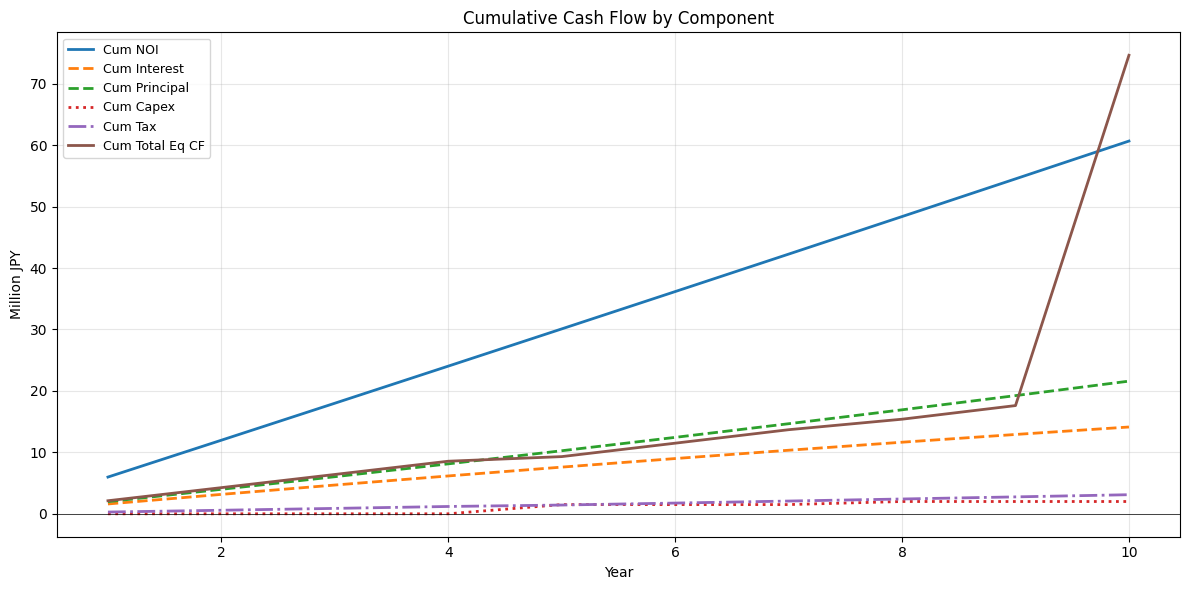

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))
years = df["year"]
for col, label, ls in [
    ("cum_noi", "Cum NOI", "-"),
    ("cum_interest", "Cum Interest", "--"),
    ("cum_principal", "Cum Principal", "--"),
    ("cum_capex", "Cum Capex", ":"),
    ("cum_tax", "Cum Tax", "-."),
    ("cum_total_equity_cf", "Cum Total Eq CF", "-"),
]:
    if col in df.columns:
        ax.plot(years, df[col] / 1e6, label=label, linewidth=2, linestyle=ls)
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Cumulative Cash Flow by Component")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()


### Annual CF: NOI / Debt Service / BTCF / ATCF

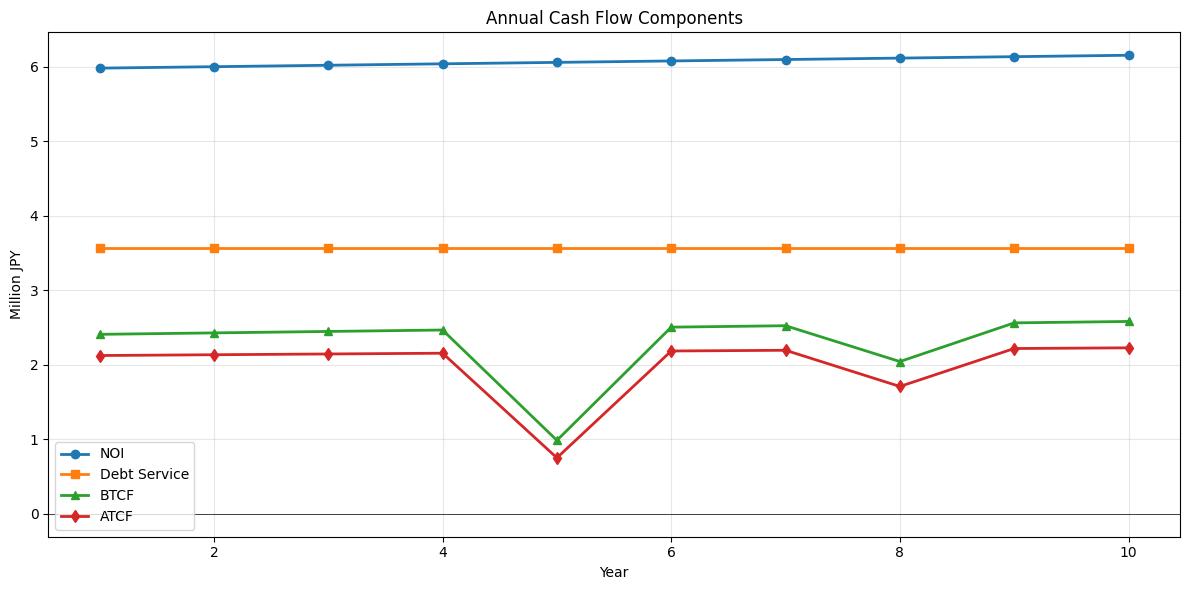

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
years = df["year"]
ax.plot(years, df["noi"]/1e6, marker="o", label="NOI", lw=2)
ax.plot(years, df["debt_service"]/1e6, marker="s", label="Debt Service", lw=2)
ax.plot(years, df["btcf"]/1e6, marker="^", label="BTCF", lw=2)
ax.plot(years, df["atcf"]/1e6, marker="d", label="ATCF", lw=2)
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Annual Cash Flow Components")
ax.legend(); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()


### B. Operating P/L 推移

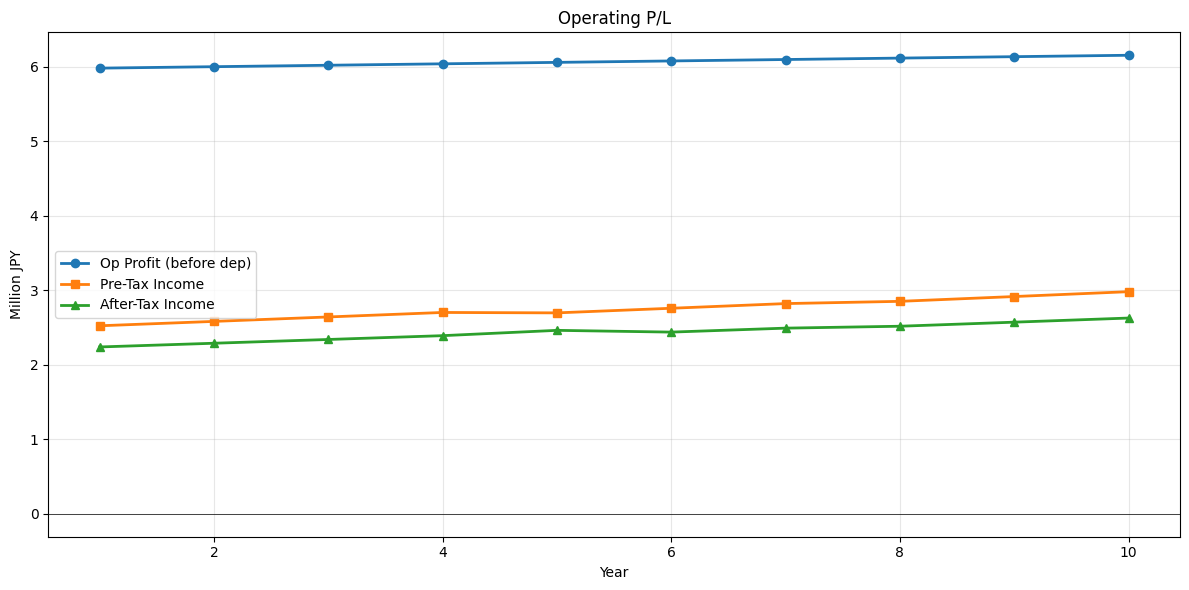

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
years = pl_df["year"]
ax.plot(years, pl_df["operating_profit_before_dep"]/1e6, marker="o", label="Op Profit (before dep)", lw=2)
ax.plot(years, pl_df["accounting_pre_tax_income"]/1e6, marker="s", label="Pre-Tax Income", lw=2)
ax.plot(years, pl_df["accounting_after_tax_income"]/1e6, marker="^", label="After-Tax Income", lw=2)
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Operating P/L")
ax.legend(); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()


### C. Market Value / Loan Balance / NAV After Tax

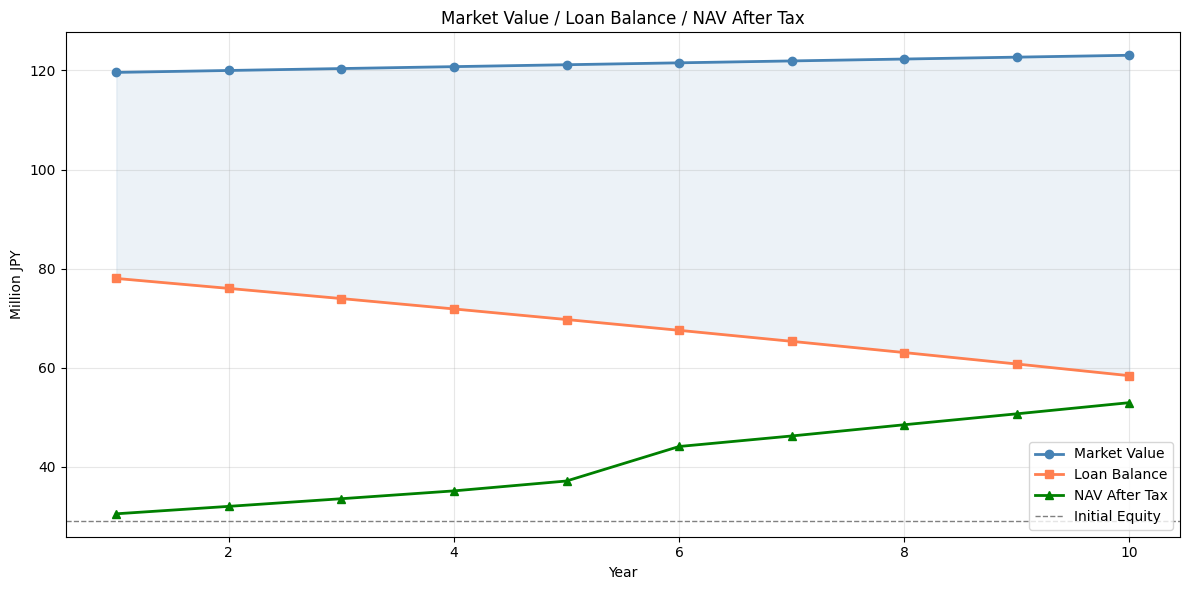

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
years = nav_df["year"]
ax.plot(years, nav_df["estimated_market_value"]/1e6, marker="o", label="Market Value", lw=2, color="steelblue")
ax.plot(years, nav_df["loan_balance_end"]/1e6, marker="s", label="Loan Balance", lw=2, color="coral")
ax.plot(years, nav_df["nav_after_tax"]/1e6, marker="^", label="NAV After Tax", lw=2, color="green")
ax.fill_between(years, nav_df["loan_balance_end"]/1e6, nav_df["estimated_market_value"]/1e6, alpha=0.1, color="steelblue")
ax.axhline(y=summary["equity_invested"]/1e6, color="gray", ls="--", lw=1, label="Initial Equity")
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Market Value / Loan Balance / NAV After Tax")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Cumulative Equity CF (Initial Equity Deducted)

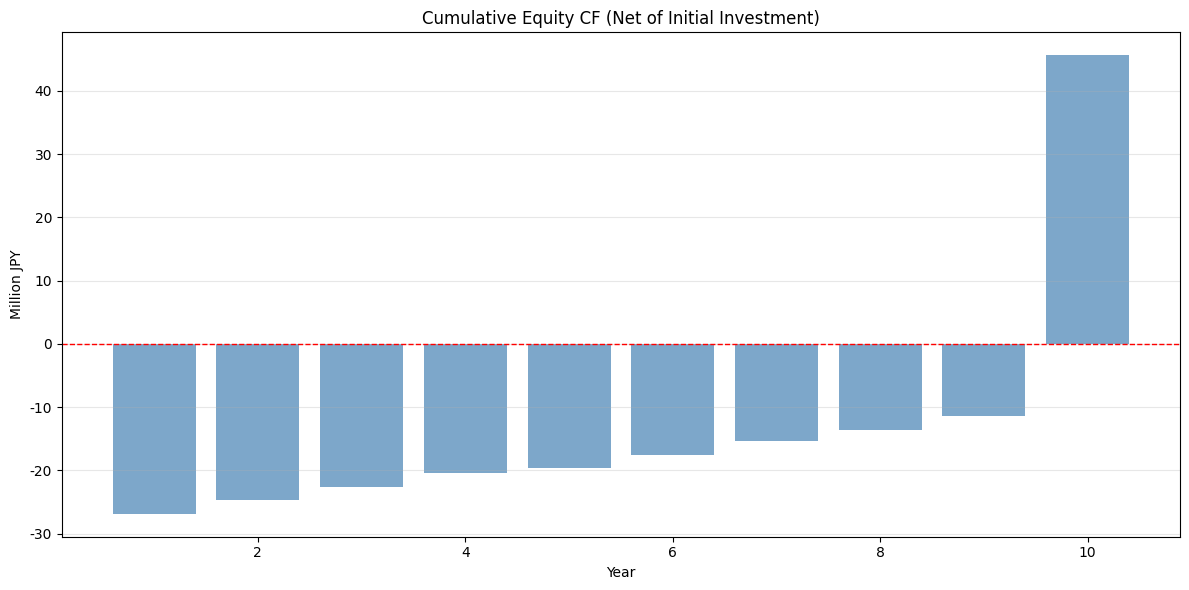

In [41]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df["year"], df["cumulative_equity_cf_with_initial"]/1e6, color="steelblue", alpha=0.7)
ax.axhline(y=0, color="red", lw=1, ls="--")
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Cumulative Equity CF (Net of Initial Investment)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


### D. Drawdown Curves (% of Peak)

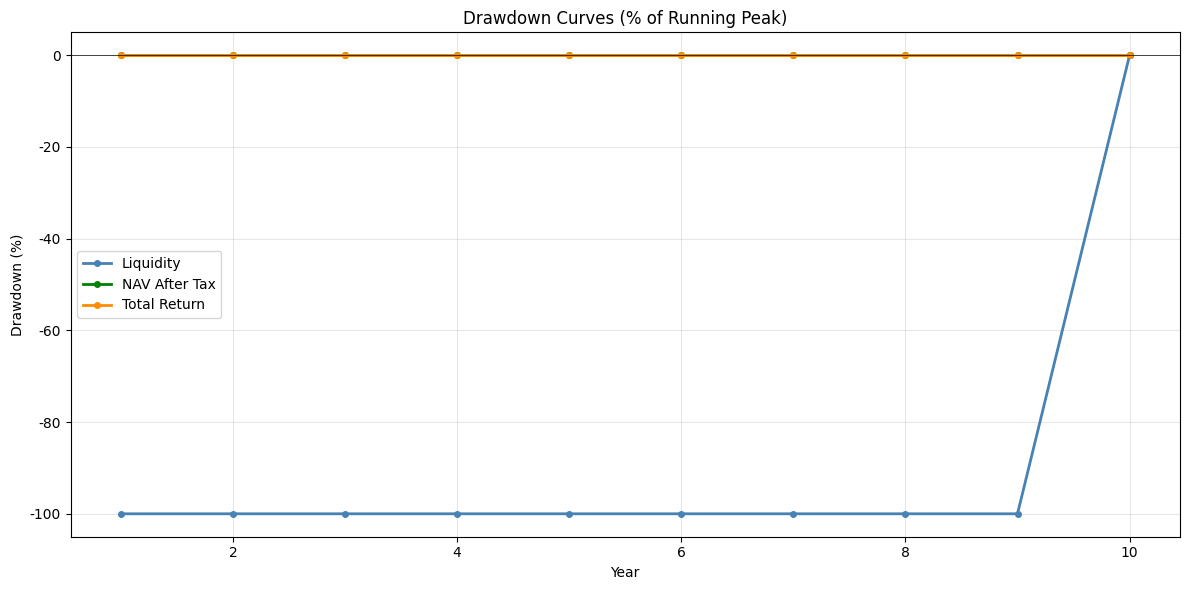

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))
colors_dd = {"Liquidity": "steelblue", "NAV After Tax": "green", "Total Return": "darkorange"}
for name, data in dd_results.items():
    dd_df = data["dd_df"]
    ax.plot(dd_df["year"], dd_df["drawdown_pct"] * 100, marker="o", markersize=4,
            label=name, lw=2, color=colors_dd.get(name, "gray"))
ax.set_xlabel("Year"); ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown Curves (% of Running Peak)")
ax.legend(); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()


### Loan Balance 推移

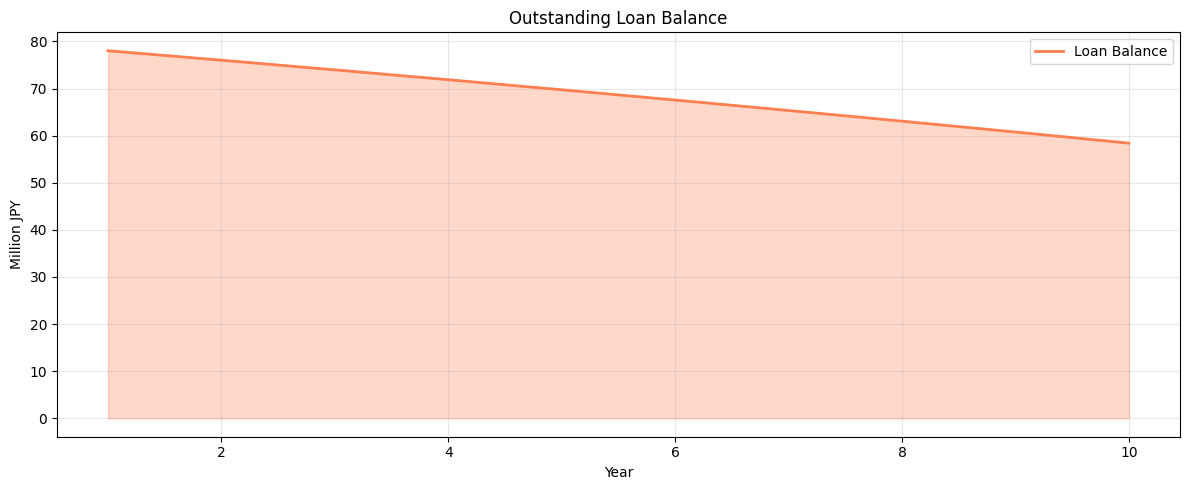

In [43]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(df["year"], df["loan_balance_end"]/1e6, alpha=0.3, color="coral")
ax.plot(df["year"], df["loan_balance_end"]/1e6, color="coral", lw=2, label="Loan Balance")
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Outstanding Loan Balance"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### E. 個人 vs 法人 所有形態比較チャート (v3)

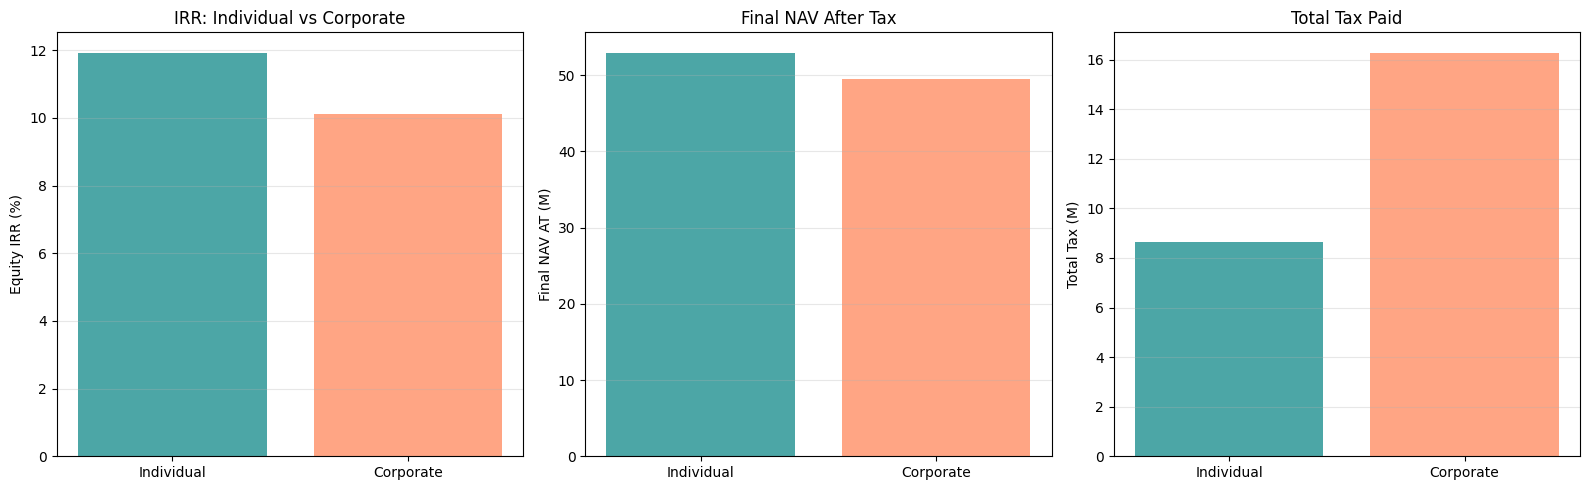

=== Ownership Comparison Summary ===


,Equity IRR,Equity Multiple,Avg CoC,Min DSCR,Final NAV AT (M),Holding Tax (M),Sale Tax (M),Total Tax (M),Tax Drag,Final Wealth (M),BE Year (Cash),Max DD% Liq,Max DD% NAV
Ownership,,,,,,,,,,,,,
Individual,11.93%,2.57,7.91%,1.67,53.0,3.1,5.3,8.7,9.84%,74.6,10,-100.00%,0.00%
Corporate,10.13%,2.31,7.91%,1.67,49.4,8.1,7.9,16.3,18.51%,67.0,10,-100.00%,0.00%


In [44]:
own_results = run_ownership_comparison(params)
own_summary_df = build_ownership_comparison_summary(own_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
irr_vals = [x if x else 0 for x in own_summary_df["Equity IRR"]]
ax.bar(own_summary_df["Ownership"], [x*100 for x in irr_vals], color=["teal", "coral"], alpha=0.7)
ax.set_ylabel("Equity IRR (%)"); ax.set_title("IRR: Individual vs Corporate")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
ax.bar(own_summary_df["Ownership"], own_summary_df["Final NAV AT (M)"], color=["teal", "coral"], alpha=0.7)
ax.set_ylabel("Final NAV AT (M)"); ax.set_title("Final NAV After Tax")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[2]
ax.bar(own_summary_df["Ownership"], own_summary_df["Total Tax (M)"], color=["teal", "coral"], alpha=0.7)
ax.set_ylabel("Total Tax (M)"); ax.set_title("Total Tax Paid")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print("=== Ownership Comparison Summary ===")
own_fmt = own_summary_df.copy()
for c in ["Equity IRR", "Avg CoC", "Tax Drag", "Max DD% Liq", "Max DD% NAV"]:
    if c in own_fmt.columns:
        own_fmt[c] = own_fmt[c].apply(lambda x: f"{x:.2%}" if x is not None else "N/A")
for c in ["Equity Multiple", "Min DSCR"]:
    if c in own_fmt.columns:
        own_fmt[c] = own_fmt[c].apply(lambda x: f"{x:.2f}")
for c in [col for col in own_fmt.columns if "(M)" in col]:
    own_fmt[c] = own_fmt[c].apply(lambda x: f"{x:,.1f}")
own_fmt.set_index("Ownership")


### F. Tax Bridge チャート (v3)

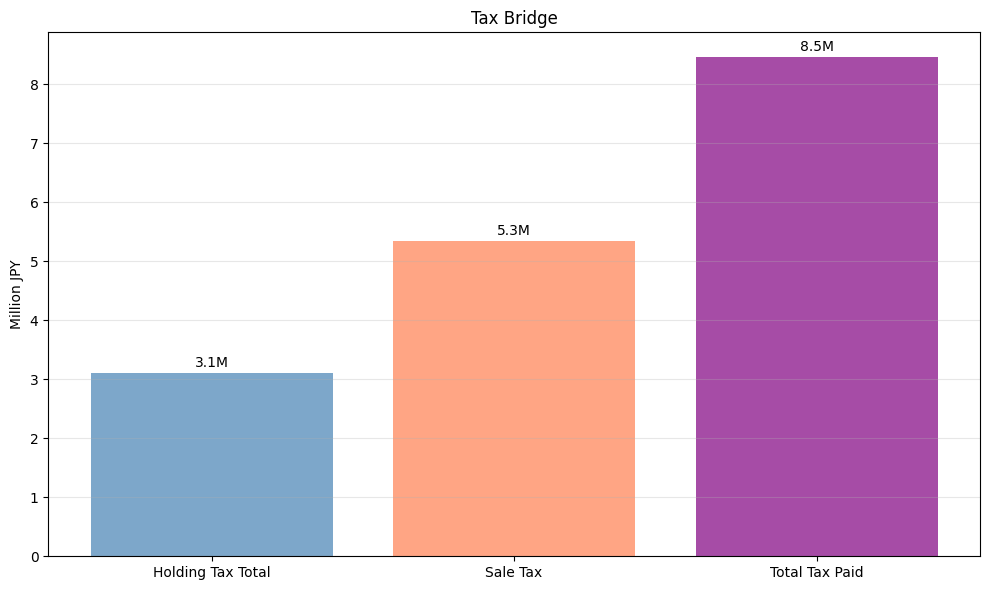

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))
categories = list(tax_bridge.keys())
values_tb = [v / 1e6 for v in tax_bridge.values()]
colors_tb = ["steelblue", "coral", "purple"]
ax.bar(categories, values_tb, color=colors_tb, alpha=0.7)
ax.set_ylabel("Million JPY"); ax.set_title("Tax Bridge")
for i, (c, v) in enumerate(zip(categories, values_tb)):
    ax.text(i, v + 0.1, f"{v:,.1f}M", ha="center", fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


### G. Exit Waterfall チャート (v3)

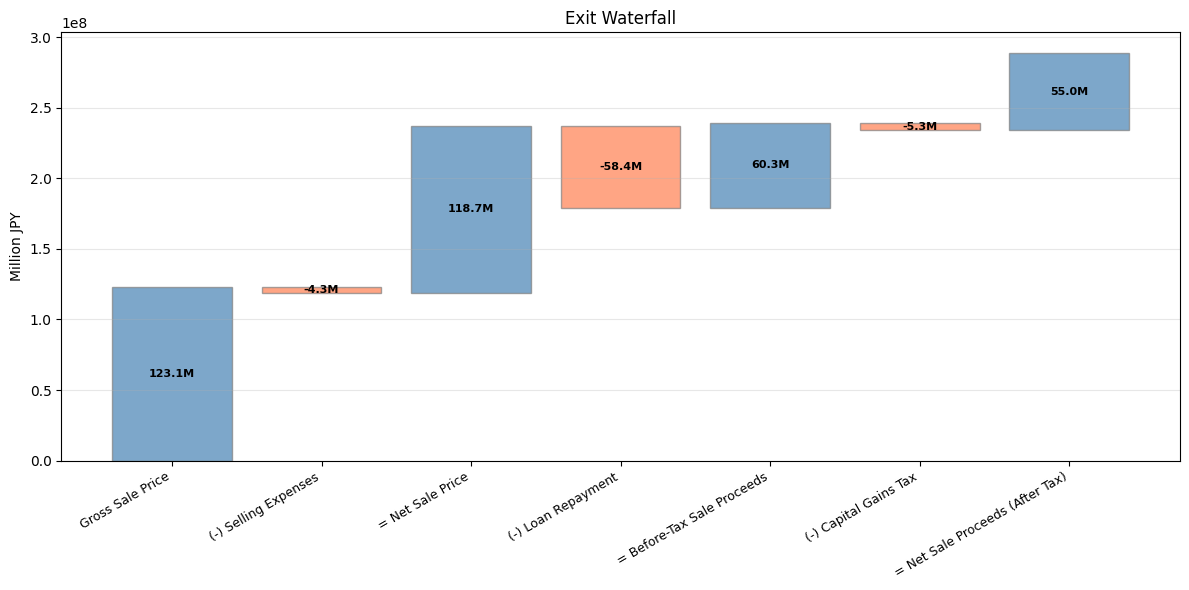

In [46]:
wf_df = build_exit_waterfall_table(summary, sale_detail)
fig, ax = plt.subplots(figsize=(12, 6))

items = wf_df["Item"].tolist()
amounts = wf_df["Amount"].tolist()

cumulative = 0
bottoms = []
heights = []
colors_wf = []
for amt in amounts:
    if amt >= 0:
        bottoms.append(cumulative)
        heights.append(amt)
        colors_wf.append("steelblue")
        cumulative += amt
    else:
        cumulative += amt
        bottoms.append(cumulative)
        heights.append(abs(amt))
        colors_wf.append("coral")

ax.bar(range(len(items)), heights, bottom=bottoms, color=colors_wf, alpha=0.7, edgecolor="gray")
ax.set_xticks(range(len(items)))
ax.set_xticklabels(items, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Million JPY")
ax.set_title("Exit Waterfall")

for i, (b, h, a) in enumerate(zip(bottoms, heights, amounts)):
    y_pos = b + h / 2
    ax.text(i, y_pos, f"{a/1e6:,.1f}M", ha="center", va="center", fontsize=8, fontweight="bold")

ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


### H. リファイナンス有無比較 (v3)

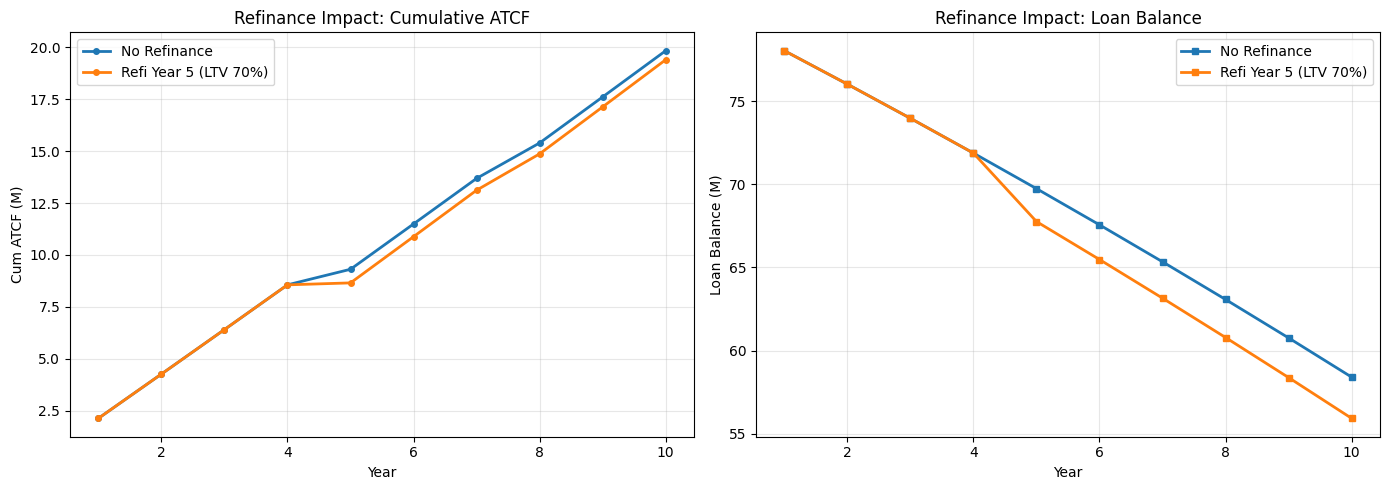

In [47]:
refi_scenarios = [
    {"label": "No Refinance", "overrides": {"enable_refinance": False}},
    {"label": "Refi Year 5 (LTV 70%)", "overrides": {
        "enable_refinance": True, "refinance_year": 5,
        "refinance_ltv": 0.70, "refinance_interest_rate": 0.018,
        "refinance_term_years": 25, "refinance_fee_rate": 0.01,
    }},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sc in refi_scenarios:
    df_r, _, m_r, p_r = run_scenario(params, sc["overrides"])
    df_r, _ = add_cumulative_cashflow_columns(df_r, p_r)
    axes[0].plot(df_r["year"], df_r["cumulative_atcf"]/1e6, marker="o", markersize=4, label=sc["label"], lw=2)
    axes[1].plot(df_r["year"], df_r["loan_balance_end"]/1e6, marker="s", markersize=4, label=sc["label"], lw=2)

axes[0].set_xlabel("Year"); axes[0].set_ylabel("Cum ATCF (M)")
axes[0].set_title("Refinance Impact: Cumulative ATCF")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Year"); axes[1].set_ylabel("Loan Balance (M)")
axes[1].set_title("Refinance Impact: Loan Balance")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## シナリオ分析


=== Rent Growth Sensitivity ===
Rent Growth  Equity IRR  Eq Multiple
      -1.0%       7.79%        1.86x
       0.0%      10.64%        2.33x
       0.5%      11.93%        2.57x
       1.0%      13.16%        2.83x
       2.0%      15.40%        3.36x


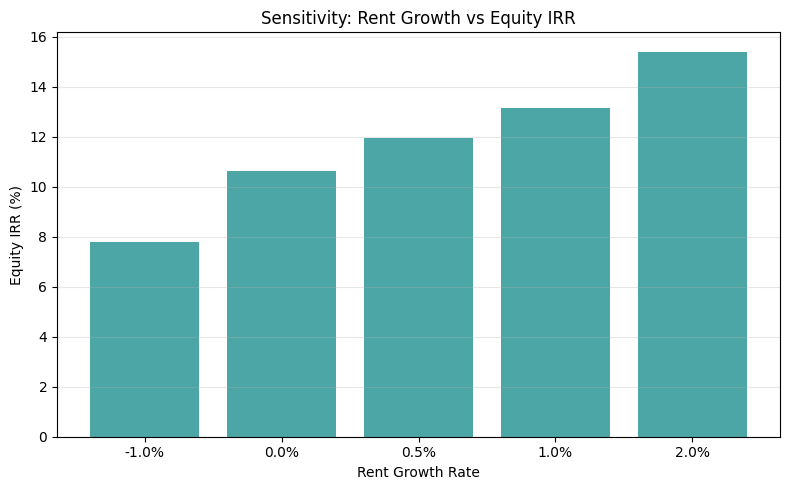

In [48]:
# --- シナリオ 1: 賃料成長率 ---
rent_growth_scenarios = [-0.01, 0.0, 0.005, 0.01, 0.02]
results_rent = []
for rg in rent_growth_scenarios:
    _, _, m, _ = run_scenario(params, {"rent_growth_rate": rg})
    results_rent.append({"Rent Growth": f"{rg:.1%}", "Equity IRR": m["equity_irr"],
                         "Eq Multiple": m["equity_multiple"]})

print("=== Rent Growth Sensitivity ===")
print(pd.DataFrame(results_rent).to_string(index=False,
    float_format=lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}x"))

fig, ax = plt.subplots(figsize=(8, 5))
irrs = [r["Equity IRR"] or 0 for r in results_rent]
ax.bar([r["Rent Growth"] for r in results_rent], [x*100 for x in irrs], color="teal", alpha=0.7)
ax.set_xlabel("Rent Growth Rate"); ax.set_ylabel("Equity IRR (%)")
ax.set_title("Sensitivity: Rent Growth vs Equity IRR")
ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()


In [49]:
# --- シナリオ 2: 出口 Cap Rate ---
exit_cap_scenarios = [0.035, 0.04, 0.045, 0.05, 0.055, 0.06]
results_exit = []
for ec in exit_cap_scenarios:
    _, s, m, _ = run_scenario(params, {"exit_cap_rate": ec})
    results_exit.append({"Exit Cap": f"{ec:.1%}", "Equity IRR": m["equity_irr"],
                         "Sale Price": s["sale_price_selected"], "Net Proceeds": s["net_sale_proceeds"]})

df_exit = pd.DataFrame(results_exit)
df_ed = df_exit.copy()
df_ed["Equity IRR"] = df_ed["Equity IRR"].apply(lambda x: f"{x:.2%}" if x else "N/A")
df_ed["Sale Price"] = df_ed["Sale Price"].apply(lambda x: f"{x:,.0f}")
df_ed["Net Proceeds"] = df_ed["Net Proceeds"].apply(lambda x: f"{x:,.0f}")
print("=== Exit Cap Rate Sensitivity ===")
print(df_ed.to_string(index=False))


=== Exit Cap Rate Sensitivity ===
Exit Cap Equity IRR  Sale Price Net Proceeds
    3.5%     17.06% 175,795,253   95,346,058
    4.0%     15.18% 153,820,846   78,448,613
    4.5%     13.49% 136,729,641   65,306,155
    5.0%     11.93% 123,056,677   54,792,189
    5.5%     10.48% 111,869,706   46,189,853
    6.0%      9.11% 102,547,231   39,021,240


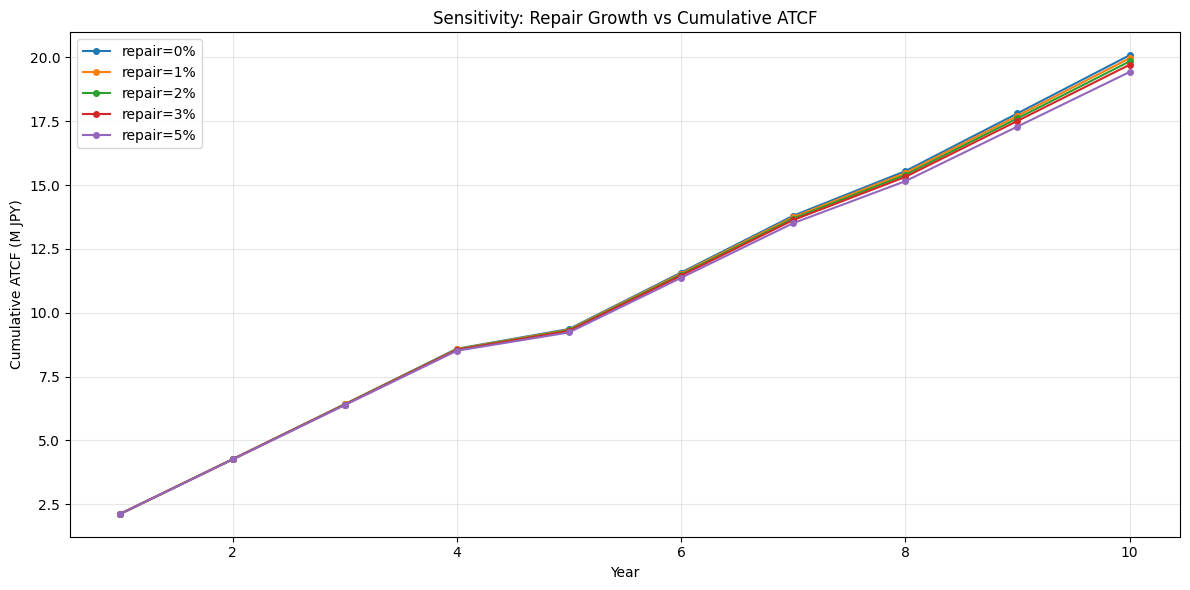

In [50]:
# --- シナリオ 3: 修繕費成長率 ---
fig, ax = plt.subplots(figsize=(12, 6))
for rg in [0.0, 0.01, 0.02, 0.03, 0.05]:
    df_s, _, _, _ = run_scenario(params, {"repair_growth_rate": rg})
    ax.plot(df_s["year"], df_s["cumulative_atcf"]/1e6, marker="o", markersize=4, label=f"repair={rg:.0%}")
ax.set_xlabel("Year"); ax.set_ylabel("Cumulative ATCF (M JPY)")
ax.set_title("Sensitivity: Repair Growth vs Cumulative ATCF")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [51]:
# --- シナリオ 4: 売却方法比較 ---
methods = ["cap_rate", "component_growth"]
comp = []
for method in methods:
    _, s, m, _ = run_scenario(params, {"exit_price_method": method})
    comp.append({"Method": method, "Sale Price": f"{s['sale_price_selected']:,.0f}",
                 "Net Proceeds": f"{s['net_sale_proceeds']:,.0f}",
                 "Equity IRR": f"{m['equity_irr']:.2%}" if m["equity_irr"] else "N/A",
                 "Eq Multiple": f"{m['equity_multiple']:.2f}x"})
print("=== Exit Method Comparison ===")
print(pd.DataFrame(comp).to_string(index=False))


=== Exit Method Comparison ===
          Method  Sale Price Net Proceeds Equity IRR Eq Multiple
        cap_rate 123,056,677   54,792,189     11.93%       2.57x
component_growth 116,603,397   49,829,873     11.12%       2.40x


### 二次元感応度テーブル（Equity IRR）

In [52]:
rent_vals = [-0.005, 0.0, 0.005, 0.01, 0.015]
exit_vals = [0.04, 0.045, 0.05, 0.055, 0.06]
matrix = {}
for rg in rent_vals:
    row = {}
    for ec in exit_vals:
        _, _, m, _ = run_scenario(params, {"rent_growth_rate": rg, "exit_cap_rate": ec})
        irr = m["equity_irr"]
        row[f"Exit {ec:.1%}"] = f"{irr:.2%}" if irr is not None else "N/A"
    matrix[f"Rent {rg:+.1%}"] = row
df_matrix = pd.DataFrame(matrix).T
df_matrix.index.name = "Rent Growth \\ Exit Cap"
print("=== Equity IRR Sensitivity Matrix ===")
df_matrix


=== Equity IRR Sensitivity Matrix ===


,Exit 4.0%,Exit 4.5%,Exit 5.0%,Exit 5.5%,Exit 6.0%
Rent Growth \ Exit Cap,,,,,
Rent -0.5%,12.77%,10.96%,9.27%,7.66%,5.90%
Rent +0.0%,14.01%,12.26%,10.64%,9.12%,7.67%
Rent +0.5%,15.18%,13.49%,11.93%,10.48%,9.11%
Rent +1.0%,16.31%,14.66%,13.16%,11.76%,10.45%
Rent +1.5%,17.38%,15.77%,14.31%,12.96%,11.70%


## 表11: Multi-Metric シナリオ比較

In [53]:
scenario_list = [
    {"label": "Base Case",           "overrides": {}},
    {"label": "Rent -1%",            "overrides": {"rent_growth_rate": -0.01}},
    {"label": "Rent +2%",            "overrides": {"rent_growth_rate": 0.02}},
    {"label": "Exit Cap 4%",         "overrides": {"exit_cap_rate": 0.04}},
    {"label": "Exit Cap 6%",         "overrides": {"exit_cap_rate": 0.06}},
    {"label": "Component Growth",    "overrides": {"exit_price_method": "component_growth"}},
    {"label": "High Repair (5%)",    "overrides": {"repair_growth_rate": 0.05}},
    {"label": "Interest 3%",         "overrides": {"interest_rate": 0.03}},
    {"label": "Hold 20Y",            "overrides": {"hold_period_years": 20}},
]

scenario_summary_df = build_extended_scenario_summary(params, scenario_list)

fmt_df = scenario_summary_df.copy()
for c in ["Equity IRR", "Avg CoC", "Tax Drag"]:
    if c in fmt_df.columns:
        fmt_df[c] = fmt_df[c].apply(lambda x: f"{x:.2%}" if x else "N/A")
fmt_df["Equity Multiple"] = fmt_df["Equity Multiple"].apply(lambda x: f"{x:.2f}x")
fmt_df["Min DSCR"] = fmt_df["Min DSCR"].apply(lambda x: f"{x:.2f}")
fmt_df["Min ICR"] = fmt_df["Min ICR"].apply(lambda x: f"{x:.2f}")
fmt_df["BE Year (Cash)"] = fmt_df["BE Year (Cash)"].apply(lambda x: str(int(x)) if x else "N/A")
for c in [col for col in fmt_df.columns if "(M)" in col]:
    fmt_df[c] = fmt_df[c].apply(lambda x: f"{x:,.1f}")
for c in ["Max DD% Liq", "Max DD% NAV", "Max DD% TR"]:
    if c in fmt_df.columns:
        fmt_df[c] = fmt_df[c].apply(lambda x: f"{x:.1%}")
print("=== Multi-Metric Scenario Comparison ===")
fmt_df.set_index("Scenario")


=== Multi-Metric Scenario Comparison ===


,Equity IRR,Equity Multiple,Avg CoC,Min DSCR,Min ICR,BE Year (Cash),Peak Neg CF (M),Final NAV AT (M),Max DD% Liq,Max DD% NAV,Max DD% TR,Tax Total (M),Tax Drag
Scenario,,,,,,,,,,,,,
Base Case,11.93%,2.57x,7.91%,1.67,3.74,10,-26.9,53.0,-100.0%,0.0%,0.0%,8.7,9.84%
Rent -1%,7.79%,1.86x,6.08%,1.43,3.74,10,-26.9,36.7,-100.0%,0.0%,0.0%,3.7,5.97%
Rent +2%,15.40%,3.36x,9.90%,1.67,3.74,10,-26.9,71.3,-100.0%,0.0%,0.0%,14.4,12.37%
Exit Cap 4%,15.18%,3.39x,7.91%,1.67,3.74,10,-26.9,76.6,-100.0%,0.0%,0.0%,14.7,12.48%
Exit Cap 6%,9.11%,2.03x,7.91%,1.67,3.74,10,-26.9,37.2,-100.0%,0.0%,-100.0%,4.6,6.80%
Component Growth,11.12%,2.40x,7.91%,1.67,3.74,10,-26.9,48.0,-100.0%,0.0%,-100.0%,7.4,9.04%
High Repair (5%),11.58%,2.50x,7.74%,1.67,3.74,10,-26.9,51.3,-100.0%,0.0%,0.0%,8.2,9.55%
Interest 3%,10.44%,2.36x,6.16%,1.47,2.49,10,-27.3,50.6,-100.0%,0.0%,0.0%,7.6,8.61%
Hold 20Y,10.13%,4.22x,8.58%,1.67,3.74,15,-26.9,78.2,-100.0%,0.0%,0.0%,17.6,10.14%


### I. シナリオ別指標バーチャート

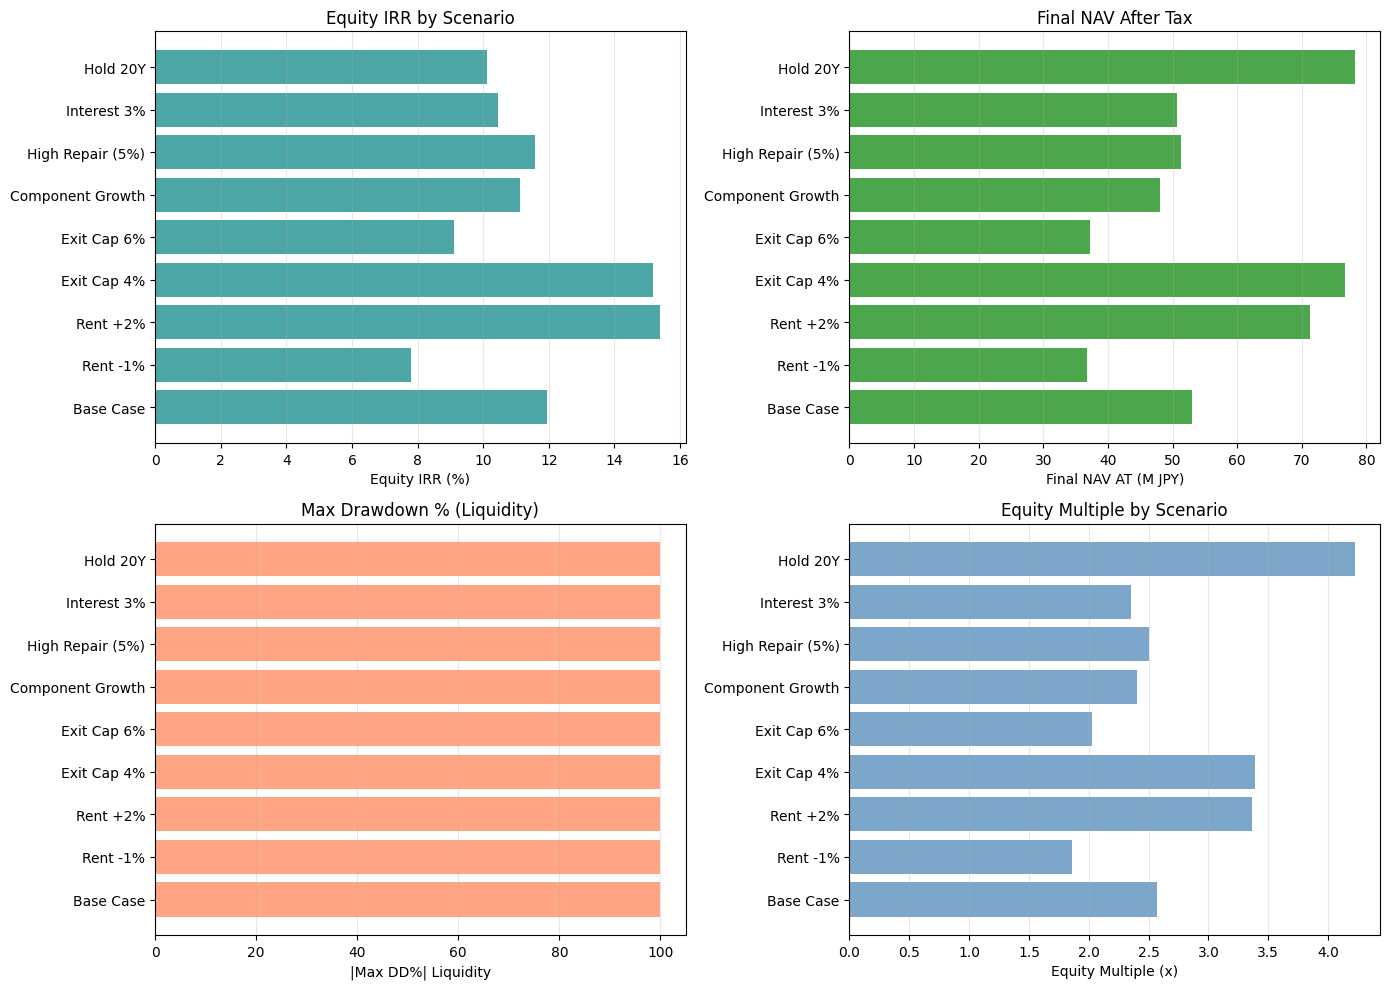

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
raw = scenario_summary_df

ax = axes[0, 0]
irr_vals = [x if x else 0 for x in raw["Equity IRR"]]
ax.barh(raw["Scenario"], [x*100 for x in irr_vals], color="teal", alpha=0.7)
ax.set_xlabel("Equity IRR (%)"); ax.set_title("Equity IRR by Scenario")
ax.grid(True, alpha=0.3, axis="x")

ax = axes[0, 1]
ax.barh(raw["Scenario"], raw["Final NAV AT (M)"], color="green", alpha=0.7)
ax.set_xlabel("Final NAV AT (M JPY)"); ax.set_title("Final NAV After Tax")
ax.grid(True, alpha=0.3, axis="x")

ax = axes[1, 0]
ax.barh(raw["Scenario"], raw["Max DD% Liq"].abs()*100, color="coral", alpha=0.7)
ax.set_xlabel("|Max DD%| Liquidity"); ax.set_title("Max Drawdown % (Liquidity)")
ax.grid(True, alpha=0.3, axis="x")

ax = axes[1, 1]
ax.barh(raw["Scenario"], raw["Equity Multiple"], color="steelblue", alpha=0.7)
ax.set_xlabel("Equity Multiple (x)"); ax.set_title("Equity Multiple by Scenario")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout(); plt.show()


## 表12: v3 拡張シナリオ比較（所有形態 × CAPEX × リファイナンス × みなし取得費）

In [55]:
v3_scenario_df = build_v3_extended_scenario_summary(params)

v3_fmt = v3_scenario_df.copy()
for c in ["Equity IRR", "Avg CoC", "Tax Drag"]:
    if c in v3_fmt.columns:
        v3_fmt[c] = v3_fmt[c].apply(lambda x: f"{x:.2%}" if x else "N/A")
v3_fmt["Equity Multiple"] = v3_fmt["Equity Multiple"].apply(lambda x: f"{x:.2f}x")
v3_fmt["Min DSCR"] = v3_fmt["Min DSCR"].apply(lambda x: f"{x:.2f}")
v3_fmt["Min ICR"] = v3_fmt["Min ICR"].apply(lambda x: f"{x:.2f}")
v3_fmt["BE Year (Cash)"] = v3_fmt["BE Year (Cash)"].apply(lambda x: str(int(x)) if x else "N/A")
for c in [col for col in v3_fmt.columns if "(M)" in col]:
    v3_fmt[c] = v3_fmt[c].apply(lambda x: f"{x:,.1f}")
for c in ["Max DD% Liq", "Max DD% NAV", "Max DD% TR"]:
    if c in v3_fmt.columns:
        v3_fmt[c] = v3_fmt[c].apply(lambda x: f"{x:.1%}")
print("=== v3 Extended Scenario Comparison ===")
v3_fmt.set_index("Scenario")


=== v3 Extended Scenario Comparison ===


,Equity IRR,Equity Multiple,Avg CoC,Min DSCR,Min ICR,BE Year (Cash),Peak Neg CF (M),Final NAV AT (M),Max DD% Liq,Max DD% NAV,Max DD% TR,Tax Total (M),Tax Drag
Scenario,,,,,,,,,,,,,
Indi-expense_all,11.93%,2.57x,7.91%,1.67,3.74,10,-26.9,52.8,-100.0%,0.0%,0.0%,8.7,9.82%
Indi-capitalize_all,11.93%,2.57x,7.91%,1.67,3.74,10,-26.9,53.0,-100.0%,0.0%,0.0%,8.6,9.85%
Indi-mixed_schedule,11.93%,2.57x,7.91%,1.67,3.74,10,-26.9,53.0,-100.0%,0.0%,0.0%,8.7,9.84%
Corp-expense_all,10.16%,2.31x,7.91%,1.67,3.74,10,-27.3,49.1,-100.0%,0.0%,0.0%,16.3,18.30%
Corp-capitalize_all,10.11%,2.31x,7.91%,1.67,3.74,10,-27.3,49.5,-100.0%,0.0%,0.0%,16.3,18.57%
Corp-mixed_schedule,10.13%,2.31x,7.91%,1.67,3.74,10,-27.3,49.4,-100.0%,0.0%,0.0%,16.3,18.51%
Indi-Refi ON,12.18%,2.64x,7.82%,1.67,3.74,10,-26.9,55.4,-100.0%,0.0%,0.0%,8.8,10.02%
Indi-Deemed ON,11.93%,2.57x,7.91%,1.67,3.74,10,-26.9,53.0,-100.0%,0.0%,0.0%,8.7,9.84%


---
## 📖 用語解説 — シナリオ分析・Multi-Metric指標

### リターン指標

| 略称 / 用語 | 定義 |
|---|---|
| **Equity IRR** | Equity Internal Rate of Return。自己資金に対する時間加重収益率。初期投資・毎年のATCF・売却益を考慮した複利ベース指標。 |
| **Project IRR** | レバレッジなし（全額自己資金）ベースのIRR。借入効果を除いた物件固有の収益力を示す。 |
| **Cap Rate**（還元利回り） | NOI ÷ 物件価格。物件の純収益力を示す基本利回り。 |
| **Equity Multiple**（資金倍率） | 累積手取りCF ÷ 初期自己資金。「2.0x」なら自己資金が2倍になったことを意味する。 |
| **Avg CoC**（Average Cash on Cash） | 期間平均ATCF ÷ 自己資金。年次の現金利回りの平均値。 |
| **NAV AT**（税引後純資産価値） | 推定市場価値 − 借入残高 − 繰延譲渡税。清算後に手元に残る純資産の推定値。 |

### リスク・ローン指標

| 略称 / 用語 | 定義 |
|---|---|
| **DSCR**（Debt Service Coverage Ratio） | NOI ÷ 元利返済額。1.0未満では返済がNOIを超え赤字返済。不動産融資では1.2以上が目安。 |
| **ICR**（Interest Coverage Ratio） | NOI ÷ 支払利息。利息の何倍のNOIを生んでいるかを示す。 |
| **Max DD%**（最大ドローダウン率） | ピーク値比での最大下落率。投資リスクの大きさを示す。 |
| **BE Year（Cash）**（キャッシュ回収年） | 累積ATCFが初期自己資金を上回った年。 |

### 税務指標

| 略称 / 用語 | 定義 |
|---|---|
| **Tax Drag**（税負担率） | 税金による収益圧迫度 = 総税負担 ÷ 税引前総収益。高いほど税コストが大きい。 |
| **Holding Tax Total**（保有税合計） | 保有期間中の所得税・住民税等の累計額。 |
| **Sale Tax**（譲渡税） | 売却益に対して発生する譲渡所得税の額。 |

### 所有形態・CAPEX

| 略称 / 用語 | 定義 |
|---|---|
| **個人所有（individual）** | 所得税・住民税・復興税の累進課税。保有5年超で長期譲渡（約20%）の軽減税率。 |
| **法人所有（corporate）** | 法人実効税率が一律適用。本モデルでは配当・役員報酬の二重課税は未対応。 |
| **CAPEX処理モード** | expense_all（全額費用処理）/ capitalize_all（全額資産計上）/ mixed_schedule（年別混合）の3モード。 |
| **みなし取得費（Deemed）** | 売却価格×5%を取得費とみなす税務特例（実際の取得費証明困難時）。 |
| **Refi**（リファイナンス） | 既存ローンを借り換えること。金利低下・Cash Out・ローン期間変更が主な目的。 |


---
## v3 で追加したこと

### 税務精緻化
1. **累進所得税率** — `use_progressive_tax=True` で日本の所得税率テーブル（5%～45%）を適用
2. **事業税** — `optional_business_tax_rate` で任意加算
3. **みなし取得費** — `use_deemed_acquisition_cost_fallback=True` で売却価格×5% をフォールバック

### CAPEX 税務処理
4. **3 モード** — `expense_all` / `capitalize_all` / `mixed_schedule`
5. **資産計上 Capex の追加償却** — `capital_improvement_depr_life_years` で耐用年数指定
6. **CAPEX 税務スケジュール** — `build_capex_tax_schedule()` で年次の費用/資本化/償却を算出

### 売却税務
7. **売却諸費用明細** — `selling_expense_schedule_mode` で rate / itemized 切替
8. **Exit Waterfall** — `build_exit_waterfall_table()` でフォール形式の分解
9. **Tax Bridge** — `build_tax_bridge_table()` で保有税+売却税の全体像

### 所有形態比較
10. **個人 vs 法人** — `run_ownership_comparison()` + `build_ownership_comparison_summary()` で 14+ 指標を横並び
11. **比較チャート** — IRR / NAV / Tax の 3 パネルバーチャート

### 資本政策
12. **リファイナンス** — `enable_refinance=True` で 1 回のリファイナンスイベント
13. **繰上返済** — `prepayment_schedule` で年次の繰上返済額を指定
14. **資本政策テーブル** — `build_capital_events_table()` でイベント一覧

### 拡張指標
15. **Holding Tax Total / Sale Tax Total / Total Tax Paid** — 税金の累計
16. **Interest Paid Total** — 利払いの累計
17. **Final After-Tax Wealth** — 最終的な税引後富
18. **Tax Drag Ratio** — 税負担率

### 拡張シナリオ
19. **v3 多軸シナリオ** — 所有形態 × CAPEX モード × リファイナンス × みなし取得費

### 新規関数
- `compute_progressive_income_tax(taxable_income)`
- `build_capex_tax_schedule(params, years)`
- `refine_sale_tax_calculation(params, summary)`
- `run_ownership_comparison(base_params)`
- `build_ownership_comparison_summary(results)`
- `build_capital_events_table(df, params)`
- `build_tax_bridge_table(df, params, summary, sale_detail)`
- `build_exit_waterfall_table(summary, sale_detail)`
- `build_v3_extended_scenario_summary(base_params)`

---
## v3 の限界

- **年次モデル**: 月次 CF をモデル化していない
- **欠損繰越なし**: 個人 3 年 / 法人 10 年の欠損繰越は未対応
- **累進税率は不動産所得のみ**: 給与所得等との合算（損益通算）は未対応
- **Depreciation Recapture**: 建物部分の超過償却に対する追加課税は未モデル化
- **消費税・取得税**: 個別の間接税は `acquisition_cost_rate` に含め簡易化
- **NAV は推定値**: Cap Rate モードでは当年 NOI / exit_cap_rate（保守的推定）
- **リファイナンスは 1 回のみ**: 複数回のリファイナンスは未対応
- **変動金利未対応**: 金利は固定値（リファイナンス後も固定）

---
## v4 で追加したいこと

### 税務
- [ ] 欠損繰越（個人 3 年・法人 10 年）
- [ ] 損益通算（給与所得等との合算）
- [ ] Depreciation Recapture の精緻計算
- [ ] 消費税・登録免許税・不動産取得税の個別モデル化

### モデル
- [ ] **月次化**: 年次 → 月次 CF
- [ ] **変動金利**: 金利の時系列変動・スワップ
- [ ] **空室率動的モデル**: 築年数・エリア特性に応じた変動
- [ ] **複数回リファイナンス**: イベントリスト方式

### 分析
- [ ] **ポートフォリオ**: 複数物件の CF 統合
- [ ] **Monte Carlo**: 確率変動シミュレーション
- [ ] **感応度ヒートマップ**: 2 変数 × 複数指標
- [ ] **売却タイミング最適化**: 各年の売却 IRR/NAV 比較

### UX
- [ ] Streamlit / Gradio ダッシュボード
- [ ] クラス設計（Property / Loan / TaxCalculator）
- [ ] YAML/JSON 設定ファイル
- [ ] PDF レポート自動生成


---
# Streamlit アプリ 起動 / 停止

`real_estate_app/` をローカル Web アプリとして起動します。  
URL: **http://127.0.0.1:8501**


In [58]:
## Streamlit 起動セル
import subprocess, sys, os, time

_APP_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "real_estate_app")
if not os.path.isdir(_APP_DIR):
    _APP_DIR = os.path.expanduser("~/projects/notebooks/real_estate_app")

_streamlit_proc = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "app.py",
     "--server.address=127.0.0.1", "--server.port=8501",
     "--server.headless=true", "--browser.gatherUsageStats=false"],
    cwd=_APP_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)

time.sleep(2)
if _streamlit_proc.poll() is None:
    print(f"Streamlit 起動成功 (PID: {_streamlit_proc.pid})")
    print("URL: http://127.0.0.1:8501")
else:
    print("起動失敗")
    print(_streamlit_proc.stderr.read().decode())


Streamlit 起動成功 (PID: 39619)
URL: http://127.0.0.1:8501


In [57]:
## Streamlit 停止セル
try:
    _streamlit_proc.terminate()
    _streamlit_proc.wait(timeout=5)
    print(f"Streamlit 停止完了 (PID: {_streamlit_proc.pid})")
except NameError:
    print("プロセスが見つかりません。先に起動セルを実行してください。")
except Exception as e:
    print(f"停止エラー: {e}")
    try:
        _streamlit_proc.kill()
        print("強制終了しました")
    except Exception:
        pass


Streamlit 停止完了 (PID: 39519)
